Name   : **Muhammad Arfani Asra**  

SID    : **D121191071**  

Thesis : **Application of Data Mining in Tuberculosis Contact Segmentation Using Clustering Techniques for Targeted Intervention (Yamali TB South Sulawesi Case Study)**

Content: **This section only contain Data Preprocessing**


# A. Import Library & Packages

In [1]:
# ===============================================
# 📥 External Library Installation
# ===============================================
!pip install adjustText googlemaps pyclustering


In [2]:
# ===============================================
# 🔧 CORE DATA MANIPULATION & SYSTEMS
# ===============================================
import pandas as pd
import numpy as np
import random
import time
import os
import re
import requests
import warnings
from datetime import datetime, timedelta
from IPython.display import display
from zoneinfo import ZoneInfo
warnings.filterwarnings("ignore")

# ===============================================
# 📊 DATA EXPLORATION & VISUALIZATION
# ===============================================
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from adjustText import adjust_text
from mpl_toolkits.mplot3d import Axes3D
from plotly.subplots import make_subplots
from scipy import stats
from scipy.spatial.distance import cdist
from typing import Union, Optional
from collections import defaultdict

# ===============================================
# 🧼 DATA PREPROCESSING & TRANSFORMATION
# ===============================================
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA

# ===============================================
# 🌍 GEOLOCATION & GOOGLE MAPS API
# ===============================================
import googlemaps
from google.colab import userdata

# ===============================================
# ⏳ UTILITIES & PROGRESS BARS
# ===============================================
from tqdm.notebook import tqdm as tqdm_notebook
from tqdm.auto import tqdm
from itertools import cycle, islice

In [3]:
# Set option to display all columns
pd.set_option('display.max_columns', None)

# B. Data Preparation

## B.1 Tuberculosis Contact Investigation Data Set

### B.1.1 Load and Read Dataset

In [4]:
DATASET_IK_PATH = userdata.get('DATASET_IK_PATH')
df_kontak = pd.read_csv(DATASET_IK_PATH)
df_kontak

,No,Tanggal Kegiatan,Fasyankes Lokasi,Nama Kontak,Jenis Kelamin,Umur,Alamat,Kontak Serumah,Batuk,Sesak Nafas,Berkeringat malam hari tanpa kegiatan,Demam meriang >1 bulan,DM,Lansia >60 th,Ibu Hamil,Perokok,Pernah berobat TBC tapi tidak tuntas,Fasyankes Rujukan,Dirujuk,Rujukan,SSR,Semester,RT/Non RT
0,1,2021-06-23,KALUKU BODOA,Dg Colleng,Laki-Laki,70,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
1,2,2021-06-23,KALUKU BODOA,Mansia,Perempuan,67,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
2,3,2021-06-23,KALUKU BODOA,Risal,Laki-Laki,38,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
3,4,2021-06-23,KALUKU BODOA,Irfan,Laki-Laki,35,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
4,5,2021-06-23,KALUKU BODOA,Risna,Perempuan,31,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166807,166808,2024-07-23,GENTUNGAN,Sitti Dg. Siang,Perempuan,58,Renggang,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,BONTONOMPO II,1,1,Gowa,2,Non RT
166808,166809,2024-07-23,GENTUNGAN,Maramis,Laki-Laki,60,Renggang,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,GENTUNGAN,0,0,Gowa,2,Non RT
166809,166810,2024-07-23,GENTUNGAN,Dg. Baji,Perempuan,50,Renggang,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,GENTUNGAN,0,0,Gowa,2,Non RT
166810,166811,2024-07-23,GENTUNGAN,Dg. Judda,Perempuan,75,Renggang,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,GENTUNGAN,0,0,Gowa,2,Non RT


In [5]:
display(df_kontak.info())
display(df_kontak.describe(include='object'))
display(df_kontak.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166812 entries, 0 to 166811
Data columns (total 23 columns):
 #   Column                                 Non-Null Count   Dtype 
---  ------                                 --------------   ----- 
 0   No                                     166812 non-null  int64 
 1   Tanggal Kegiatan                       166812 non-null  object
 2   Fasyankes Lokasi                       166812 non-null  object
 3   Nama Kontak                            166812 non-null  object
 4   Jenis Kelamin                          166812 non-null  object
 5   Umur                                   166812 non-null  int64 
 6   Alamat                                 166769 non-null  object
 7   Kontak Serumah                         166812 non-null  object
 8   Batuk                                  166812 non-null  object
 9   Sesak Nafas                            166812 non-null  object
 10  Berkeringat malam hari tanpa kegiatan  166812 non-null  object
 11  

None

,Tanggal Kegiatan,Fasyankes Lokasi,Nama Kontak,Jenis Kelamin,Alamat,Kontak Serumah,Batuk,Sesak Nafas,Berkeringat malam hari tanpa kegiatan,Demam meriang >1 bulan,DM,Lansia >60 th,Ibu Hamil,Perokok,Pernah berobat TBC tapi tidak tuntas,Fasyankes Rujukan,SSR,RT/Non RT
count,166812,166812,166812,166812,166769,166812,166812,166812,166812,166812,166812,166812,166812,166812,166812,166805,166812,166812
unique,1454,84,74550,2,9088,2,2,2,2,2,2,2,2,2,2,89,2,2
top,2022-01-10,PALLANGGA,Nurhayati,Perempuan,Jl. Sultan Abdullah,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,PALLANGGA,Kota Makassar,RT
freq,639,10818,372,85990,1343,135415,155453,163231,165113,164663,165843,152694,166513,148671,166702,10884,105299,163942


,0
No,166812
Tanggal Kegiatan,1454
Fasyankes Lokasi,84
Nama Kontak,74550
Jenis Kelamin,2
Umur,110
Alamat,9088
Kontak Serumah,2
Batuk,2
Sesak Nafas,2


In [6]:
df_kontak.head()

,No,Tanggal Kegiatan,Fasyankes Lokasi,Nama Kontak,Jenis Kelamin,Umur,Alamat,Kontak Serumah,Batuk,Sesak Nafas,Berkeringat malam hari tanpa kegiatan,Demam meriang >1 bulan,DM,Lansia >60 th,Ibu Hamil,Perokok,Pernah berobat TBC tapi tidak tuntas,Fasyankes Rujukan,Dirujuk,Rujukan,SSR,Semester,RT/Non RT
0,1,2021-06-23,KALUKU BODOA,Dg Colleng,Laki-Laki,70,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
1,2,2021-06-23,KALUKU BODOA,Mansia,Perempuan,67,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
2,3,2021-06-23,KALUKU BODOA,Risal,Laki-Laki,38,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
3,4,2021-06-23,KALUKU BODOA,Irfan,Laki-Laki,35,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT
4,5,2021-06-23,KALUKU BODOA,Risna,Perempuan,31,Jl Tinumbu Lr 149,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,KALUKU BODOA,0,0,Kota Makassar,1,RT


### B.1.2 Data Cleaning

In [7]:
df_kontak_cleaned = df_kontak.copy()

#### Columns Rename

In [8]:
# Column Header to rename
new_column_names = {
    'Tanggal Kegiatan': 'tanggal_kegiatan',
    'Fasyankes Lokasi': 'fasyankes_lokasi',
    'Nama Kontak': 'nama_kontak',
    'Jenis Kelamin': 'jenis_kelamin',
    'Umur': 'umur',
    'Kontak Serumah': 'kontak_serumah',
    'Batuk': 'batuk',
    'Sesak Nafas': 'sesak_nafas',
    'Berkeringat malam hari tanpa kegiatan': 'keringat_malam',
    'Demam meriang >1 bulan': 'demam_meriang',
    'DM': 'diabetes_mellitus',
    'Lansia >60 th': 'lansia',
    'Ibu Hamil': 'ibu_hamil',
    'Perokok': 'perokok',
    'Pernah berobat TBC tapi tidak tuntas': 'berobat_tidak_tuntas',
    'Fasyankes Rujukan': 'fasyankes_rujukan',
    'Dirujuk': 'dirujuk',
    'Rujukan': 'rujukan',
    'SSR': 'ssr'
}

cols_to_drop = {
    'No',
    'Alamat',
    'Semester',
    'RT/Non RT',
}

# Rename the columns
df_kontak_cleaned.drop(columns=cols_to_drop, inplace=True)
df_kontak_cleaned.rename(columns=new_column_names, inplace=True)

display(df_kontak_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166812 entries, 0 to 166811
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   tanggal_kegiatan      166812 non-null  object
 1   fasyankes_lokasi      166812 non-null  object
 2   nama_kontak           166812 non-null  object
 3   jenis_kelamin         166812 non-null  object
 4   umur                  166812 non-null  int64 
 5   kontak_serumah        166812 non-null  object
 6   batuk                 166812 non-null  object
 7   sesak_nafas           166812 non-null  object
 8   keringat_malam        166812 non-null  object
 9   demam_meriang         166812 non-null  object
 10  diabetes_mellitus     166812 non-null  object
 11  lansia                166812 non-null  object
 12  ibu_hamil             166812 non-null  object
 13  perokok               166812 non-null  object
 14  berobat_tidak_tuntas  166812 non-null  object
 15  fasyankes_rujukan

None

#### Handling Missing or Invalid Values

##### Handling Missing Values

In [9]:
# Check for missing values
print("Missing values in each column:")
print(df_kontak_cleaned.isnull().sum())

Missing values in each column:
tanggal_kegiatan        0
fasyankes_lokasi        0
nama_kontak             0
jenis_kelamin           0
umur                    0
kontak_serumah          0
batuk                   0
sesak_nafas             0
keringat_malam          0
demam_meriang           0
diabetes_mellitus       0
lansia                  0
ibu_hamil               0
perokok                 0
berobat_tidak_tuntas    0
fasyankes_rujukan       7
dirujuk                 0
rujukan                 0
ssr                     0
dtype: int64


In [10]:
# Handling missing values by drop the column
df_kontak_cleaned.drop(columns=['fasyankes_rujukan'], inplace=True)
df_kontak_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166812 entries, 0 to 166811
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   tanggal_kegiatan      166812 non-null  object
 1   fasyankes_lokasi      166812 non-null  object
 2   nama_kontak           166812 non-null  object
 3   jenis_kelamin         166812 non-null  object
 4   umur                  166812 non-null  int64 
 5   kontak_serumah        166812 non-null  object
 6   batuk                 166812 non-null  object
 7   sesak_nafas           166812 non-null  object
 8   keringat_malam        166812 non-null  object
 9   demam_meriang         166812 non-null  object
 10  diabetes_mellitus     166812 non-null  object
 11  lansia                166812 non-null  object
 12  ibu_hamil             166812 non-null  object
 13  perokok               166812 non-null  object
 14  berobat_tidak_tuntas  166812 non-null  object
 15  dirujuk          

In [11]:
# Check for missing values
print("Missing values in each column:")
print(df_kontak_cleaned.isnull().sum())

Missing values in each column:
tanggal_kegiatan        0
fasyankes_lokasi        0
nama_kontak             0
jenis_kelamin           0
umur                    0
kontak_serumah          0
batuk                   0
sesak_nafas             0
keringat_malam          0
demam_meriang           0
diabetes_mellitus       0
lansia                  0
ibu_hamil               0
perokok                 0
berobat_tidak_tuntas    0
dirujuk                 0
rujukan                 0
ssr                     0
dtype: int64


##### Handling Invalid Values

**Handling Invalid Values in 'umur'**

In [12]:
# Check invalid values for 'umur': If 'umur' more than 100
df_kontak_cleaned[df_kontak_cleaned['umur']>100]

,tanggal_kegiatan,fasyankes_lokasi,nama_kontak,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan,ssr
6689,2021-04-11,BATUA,Mathius,Laki-Laki,2021,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
11253,2021-12-20,TARAKANG,Mahira Rakhsyan,Perempuan,2006,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
15392,2021-10-28,KALUKU BODOA,faris,Laki-Laki,160,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
19281,2021-09-13,MALIMONGAN BARU,M. Muslimin,Laki-Laki,939,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
20495,2021-08-21,KALUKU BODOA,Jumiati,Perempuan,234,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
21727,2021-05-01,Ballaparang,Helmiati,Perempuan,230,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
21860,2021-07-14,MALIMONGAN BARU,Firman,Laki-Laki,350,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
21953,2021-07-12,MALIMONGAN BARU,Muh. Rasya Putra,Laki-Laki,120,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
104561,2022-10-11,KANJILO,Saeda,Perempuan,102,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,Gowa
150133,2023-02-28,KAMPILI,Abd. Rahman Dg. Bonto,Laki-Laki,103,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,1,1,Gowa


In [13]:
# Manual input for specific rows based on verification from original source
df_kontak_cleaned.loc[11253, 'umur'] = 6
df_kontak_cleaned.loc[19281, 'umur'] = 39

# Only get data with 'umur' value less or same as 110
df_kontak_cleaned = df_kontak_cleaned[df_kontak_cleaned['umur'] <= 110].copy()

**Handling values for inconsistency of jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA'**

In [14]:
# Check for inconsistency: jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA'
laki_laki_hamil_inconsistent = df_kontak_cleaned[(df_kontak_cleaned['jenis_kelamin'] == 'Laki-Laki') & (df_kontak_cleaned['ibu_hamil'] == 'YA')]

print("Rows where jenis_kelamin is 'Laki-Laki' and ibu_hamil is 'YA':")
if laki_laki_hamil_inconsistent.empty:
    print("No inconsistencies found.")
else:
    display(laki_laki_hamil_inconsistent)

Rows where jenis_kelamin is 'Laki-Laki' and ibu_hamil is 'YA':


,tanggal_kegiatan,fasyankes_lokasi,nama_kontak,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan,ssr
2521,2021-05-07,RAPPOKALLING,Selis,Laki-Laki,61,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,YA,YA,TIDAK,0,0,Kota Makassar
59071,2022-01-24,RAPPOKALLING,Rahim,Laki-Laki,55,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,0,0,Kota Makassar


In [15]:
# Correct inconsistency: set ibu_hamil to 'TIDAK' for rows where jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA'
df_kontak_cleaned.loc[(df_kontak_cleaned['jenis_kelamin'] == 'Laki-Laki') & (df_kontak_cleaned['ibu_hamil'] == 'YA'), 'ibu_hamil'] = 'TIDAK'

# Verify the change
laki_laki_hamil_inconsistent_after = df_kontak_cleaned[(df_kontak_cleaned['jenis_kelamin'] == 'Laki-Laki') & (df_kontak_cleaned['ibu_hamil'] == 'YA')]

print("Rows where jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA' after correction:")
if laki_laki_hamil_inconsistent_after.empty:
    print("No inconsistencies found.")
else:
    display(laki_laki_hamil_inconsistent_after)

Rows where jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA' after correction:
No inconsistencies found.


**Handling Invalid Date Values in 'tanggal_kegiatan'**

In [16]:
# Correction Map for invalid month/years
correction_map = {
    '-00-': '-10-',
    '^0020': '2020',
    '^0202': '2021',
    '^0021': '2021',
    '^0201': '2021',
    '^0022': '2022'
}


# Apply Correction Map
for pattern, replacement in correction_map.items():
    df_kontak_cleaned['tanggal_kegiatan'] = df_kontak_cleaned['tanggal_kegiatan'].str.replace(
        pat=pattern,
        repl=replacement,
        regex=True
    )

In [17]:
# Ensure that the ‘tanggal_kegiatan’ column is of the datetime type.
df_kontak_cleaned['tanggal_kegiatan'] = pd.to_datetime(df_kontak_cleaned['tanggal_kegiatan'], errors='coerce')

In [18]:
# Filter rows where 'tahun' is between 2021 and 2024
df_kontak_cleaned = df_kontak_cleaned[(df_kontak_cleaned['tanggal_kegiatan'].dt.year >= 2021) & (df_kontak_cleaned['tanggal_kegiatan'].dt.year <= 2024)].copy()

print("Unique years in df_kontak_cleaned['tanggal_kegiatan'] after dropping rows:")
print(df_kontak_cleaned['tanggal_kegiatan'].dt.year.unique())
print("")
print("Number of rows in df_kontak_cleaned:", len(df_kontak_cleaned))

Unique years in df_kontak_cleaned['tanggal_kegiatan'] after dropping rows:
[2021 2022 2023 2024]

Number of rows in df_kontak_cleaned: 166400


In [19]:
# Re-check rows with missing values in 'tanggal_kegiatan'
missing_tanggal_kegiatan_rows = df_kontak_cleaned[df_kontak_cleaned['tanggal_kegiatan'].isnull()]

print("Rows with missing values in 'tanggal_kegiatan':")
if missing_tanggal_kegiatan_rows.empty:
    print("No missing values found.")
else:
    display(missing_tanggal_kegiatan_rows)

Rows with missing values in 'tanggal_kegiatan':
No missing values found.


#### Handling duplicated rows

In [20]:
# Check for duplicate rows
duplicate_rows = df_kontak_cleaned[df_kontak_cleaned.duplicated()]

# Print the number of duplicate rows
print("Number of duplicate rows:", duplicate_rows.shape[0])

# Display the duplicate rows
if duplicate_rows.shape[0] > 0:
    print("\nDuplicate rows:")
    display(duplicate_rows)
else:
    print("\nNo duplicate rows found.")


Number of duplicate rows: 135

Duplicate rows:


,tanggal_kegiatan,fasyankes_lokasi,nama_kontak,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan,ssr
257,2021-06-15,MALIMONGAN BARU,Hasni,Perempuan,41,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
1011,2021-06-15,TAMALATE,M. Faisal Nur,Laki-Laki,47,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
5202,2021-04-03,MAMAJANG,Irma,Perempuan,38,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
6855,2021-04-15,MACCINI SOMBALA,Agus,Laki-Laki,16,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
7527,2021-03-05,Ballaparang,Al Dilla Sofyanti,Perempuan,38,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Kota Makassar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147894,2023-03-19,BAJENG,Irma,Perempuan,45,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Gowa
149316,2023-03-08,GENTUNGAN,Muh. Yusuf,Laki-Laki,34,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Gowa
159489,2023-07-10,PARIGI,Bollo,Perempuan,58,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Gowa
160622,2024-06-05,BONTONOMPO I,Dg. Tino,Perempuan,51,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,Gowa


In [21]:
# Remove duplicate rows
df_kontak_cleaned = df_kontak_cleaned.drop_duplicates().copy()

# Verify that duplicate rows have been removed
print("Number of rows after removing duplicates:", df_kontak_cleaned.shape[0])

Number of rows after removing duplicates: 166265


#### Fix Data Type Format and Standardize values

In [22]:
cols_kontak_to_standardize = [
    'nama_kontak',
    'jenis_kelamin',
    'fasyankes_lokasi',
    'ssr'
]

for col in cols_kontak_to_standardize:
    # Convert to lowercase and remove leading/trailing whitespace
    df_kontak_cleaned[col] = df_kontak_cleaned[col].str.lower().str.strip()

# Display unique values for verification
for col in cols_kontak_to_standardize:
    print(f"\nUnique values in '{col}' after standardization:")
    print(df_kontak_cleaned[col].unique())


Unique values in 'nama_kontak' after standardization:
['dg colleng' 'mansia' 'risal' ... 'sitti dg. bollo' 'feliah'
 'sitti dg. siang']

Unique values in 'jenis_kelamin' after standardization:
['laki-laki' 'perempuan']

Unique values in 'fasyankes_lokasi' after standardization:
['kaluku bodoa' 'rs balai besar kes paru masyarakat' 'malimongan baru'
 'mamajang' 'tamalate' 'maradekaya' 'bara-baraya' 'rappokalling'
 'karuwisi' 'ballaparang' 'layang' 'jongaya' 'jumpandang baru'
 'maccini sawah' 'paccerakkang' 'bira' 'batua' 'maccini sombala'
 'tamamaung' 'pampang' 'antang' 'pkm jongaya (jangan digunakan lagi)'
 'tarakang' 'andalas' 'parigi' 'gentungan' 'bontonompo i' 'moncobalang'
 'bontonompo ii' 'somba opu' 'kampili' 'kanjilo' 'pallangga' 'manuju'
 'bajeng' 'pabbentengan' 'parangloe' 'samata' 'bontomarannu'
 'pkm toddopuli' 'bangkala' 'antang perumnas' 'ibnu sina ybw umi'
 'rs umum daerah labuang baji' 'panambungan' 'kassi-kassi' 'sudiang'
 'sudiang raya' 'tamangapa' 'klinik azka nadhifa

In [23]:
display(df_kontak_cleaned.info())
display(df_kontak_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 166265 entries, 0 to 166811
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tanggal_kegiatan      166265 non-null  datetime64[ns]
 1   fasyankes_lokasi      166265 non-null  object        
 2   nama_kontak           166265 non-null  object        
 3   jenis_kelamin         166265 non-null  object        
 4   umur                  166265 non-null  int64         
 5   kontak_serumah        166265 non-null  object        
 6   batuk                 166265 non-null  object        
 7   sesak_nafas           166265 non-null  object        
 8   keringat_malam        166265 non-null  object        
 9   demam_meriang         166265 non-null  object        
 10  diabetes_mellitus     166265 non-null  object        
 11  lansia                166265 non-null  object        
 12  ibu_hamil             166265 non-null  object        
 13  pero

None

,tanggal_kegiatan,fasyankes_lokasi,nama_kontak,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan,ssr
0,2021-06-23,kaluku bodoa,dg colleng,laki-laki,70,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,kota makassar
1,2021-06-23,kaluku bodoa,mansia,perempuan,67,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,kota makassar
2,2021-06-23,kaluku bodoa,risal,laki-laki,38,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,0,kota makassar
3,2021-06-23,kaluku bodoa,irfan,laki-laki,35,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,0,kota makassar
4,2021-06-23,kaluku bodoa,risna,perempuan,31,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,kota makassar


In [24]:
# Download df_kontak_updated: df_kontak with necessary columns before encoding, normalization, and transformation
download_choice = input("Do you want to download the df_kontak_cleaned.csv? (y/n): ").lower()

if download_choice == 'y':
    df_kontak_cleaned.to_csv('df_kontak_cleaned.csv', index=False)
    print("df_kontak_cleaned.csv has been downloaded.")
else:
    print("Download skipped.")

Do you want to download the df_kontak_cleaned.csv? (y/n): y
df_kontak_cleaned.csv has been downloaded.


## B.2 Suspected TB Data Set

### B.2.1 Load and Read Dataset

In [25]:
DATASET_TERDUGA_PATH = userdata.get('DATASET_TERDUGA_PATH')
df_terduga = pd.read_csv(DATASET_TERDUGA_PATH)
df_terduga.sample(10)

,No,Tgl Laporan,Nama Lengkap,Tipe Pasien,Usia,Jenis Kelamin,Tanggal Hasil Pemeriksaan Dahak,Kota/Kab,Kecamatan,SSR,Edukasi HIV,Test HIV,Terima Hasil,Fasyankes Lokasi,Sumber Data,Lokasi Penyuluhan,Tanggal Kegiatan,Nama Kontak,Jenis Kelamin2,Umur,Alamat,Kontak Serumah,Batuk,Sesak Nafas,Berkeringat malam hari tanpa kegiatan,\n Demam meriang >1 bulan\n,DM,\n Lansia >60 th\n \n,Ibu Hamil,Perokok,Pernah berobat TBC tapi tidak tuntas,Fasyankes Rujukan,Dirujuk,Rujukan,Semester,Wilayah,Column1,Column3
19264,19265,2022-10-24,Marhamah,TCM -,40,Perempuan,2022-10-04,Kab. Gowa,Bajeng Barat,Gowa,Belum,NaN,NaN,GENTUNGAN,Investigasi,Balai desa/warga,2022-09-24,Marhamah,Perempuan,40.0,Tamattiah,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,GENTUNGAN,1.0,1.0,2,Gowa,Same,NaN
32504,32505,2023-08-25,NUR INTANG,TCM -,53,Perempuan,2023-07-27,Kota Makassar,Tallo,Kota Makassar,Belum,NaN,NaN,KALUKU BODOA,Investigasi,Lingkungan sekitar tempat tinggal,2023-07-24,NUR INTANG,Perempuan,53.0,JL.SULTAN ABDULLAH,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,KALUKU BODOA,1.0,1.0,2,Kota Makassar,Same,NaN
48649,48650,2024-02-23,Merak Dg. Ngintang,TCM -,60,Perempuan,2024-01-02,Kab. Gowa,Palangga,Gowa,Belum,NaN,NaN,KAMPILI,Investigasi,Balai desa/warga,2023-12-27,Merak Dg. Ngintang,Perempuan,60.0,Borong Bilalang,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,KAMPILI,1.0,1.0,1,Gowa,Same,2024.0
54024,54025,2024-08-31,MAJU,TCM -,61,Laki-Laki,2024-08-14,Kota Makassar,Makasar,Kota Makassar,Belum,NaN,NaN,BARA-BARAYA,Investigasi,Pertemuan RT/RW/Kel/Kec,2024-08-02,MAJU,Laki-Laki,61.0,ABLAM NO.18,TIDAK,YA,TIDAK,TIDAK,YA,TIDAK,YA,TIDAK,TIDAK,TIDAK,BARA-BARAYA,1.0,1.0,2,Kota Makassar,Same,2024.0
29403,29404,2023-05-28,St. Syamsiah,TCM -,65,Perempuan,2023-04-09,Kab. Gowa,Parangloe,Gowa,Belum,Sudah,Ya,PARANGLOE,Investigasi,Balai desa/warga,2023-04-08,St. Syamsiah,Perempuan,65.0,Parang,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,PARANGLOE,1.0,1.0,1,Gowa,Same,NaN
2466,2467,2021-06-26,Hj. Saturi,BTA -,72,Perempuan,2021-06-10,Kab. Gowa,Bajeng Barat,Gowa,Belum,NaN,NaN,GENTUNGAN,Penyuluhan mandiri,Balai desa/warga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Gowa,Different,NaN
45653,45654,2024-04-01,SARIANA,TCM -,48,Perempuan,2024-03-18,Kota Makassar,Biringkanaya,Kota Makassar,Belum,NaN,NaN,PACCERAKKANG,Investigasi,Pertemuan RT/RW/Kel/Kec,2024-03-15,SARIANA,Perempuan,48.0,JL.MAMUJU BPS,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,PACCERAKKANG,1.0,1.0,1,Kota Makassar,Same,2024.0
33180,33181,2023-09-28,RISNAWATI,TCM -,31,Perempuan,2023-09-09,Kota Makassar,Tallo,Kota Makassar,Belum,NaN,NaN,RAPPOKALLING,Investigasi,Pertemuan RT/RW/Kel/Kec,2023-09-01,RISNAWATI,Perempuan,31.0,JL.DG TANTU LR.II,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,RAPPOKALLING,1.0,1.0,2,Kota Makassar,Same,NaN
59498,59499,2024-09-29,Agung,TCM -,21,Laki-Laki,2024-09-03,Kab. Gowa,Bajeng,Gowa,Belum,Sudah,Ya,BAJENG,Investigasi,Balai desa/warga,2024-09-02,Agung,Laki-Laki,21.0,Tompo Tanaya,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,BAJENG,1.0,1.0,2,Gowa,Same,2024.0
36872,36873,2023-07-25,Zahriani,TCM -,21,Perempuan,2023-07-04,Kab. Gowa,Palangga,Gowa,Belum,Sudah,Ya,KAMPILI,Investigasi,Balai desa/warga,2023-06-21,Zahriani,Perempuan,21.0,"Cambaya, Julukanaya",TIDAK,YA,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,KAMPILI,1.0,1.0,2,Gowa,Same,NaN


In [26]:
# Trim whitespace from column names
df_terduga.columns = df_terduga.columns.str.strip()
df_terduga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61376 entries, 0 to 61375
Data columns (total 38 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   No                                     61376 non-null  int64  
 1   Tgl Laporan                            61376 non-null  object 
 2   Nama Lengkap                           61376 non-null  object 
 3   Tipe Pasien                            61376 non-null  object 
 4   Usia                                   61376 non-null  int64  
 5   Jenis Kelamin                          61376 non-null  object 
 6   Tanggal Hasil Pemeriksaan Dahak        61376 non-null  object 
 7   Kota/Kab                               61376 non-null  object 
 8   Kecamatan                              61371 non-null  object 
 9   SSR                                    61376 non-null  object 
 10  Edukasi HIV                            61274 non-null  object 
 11  Te

In [27]:
display(df_terduga.describe(include='object'))
display(df_terduga.nunique())

,Tgl Laporan,Nama Lengkap,Tipe Pasien,Jenis Kelamin,Tanggal Hasil Pemeriksaan Dahak,Kota/Kab,Kecamatan,SSR,Edukasi HIV,Test HIV,Terima Hasil,Fasyankes Lokasi,Sumber Data,Lokasi Penyuluhan,Tanggal Kegiatan,Nama Kontak,Jenis Kelamin2,Alamat,Kontak Serumah,Batuk,Sesak Nafas,Berkeringat malam hari tanpa kegiatan,Demam meriang >1 bulan,DM,Lansia >60 th,Ibu Hamil,Perokok,Pernah berobat TBC tapi tidak tuntas,Fasyankes Rujukan,Wilayah,Column1
count,61376,61376,61376,61376,61376,61376,61371,61376,61274,27987,27473,61376,61376,60835,56406,56406,56406,56404,56406,56406,56406,56406,56406,56406,56406,56406,56406,56406,56406,61376,61376
unique,365,37854,9,2,1444,2,27,2,2,2,2,65,5,11,1254,34729,2,17791,2,2,2,2,2,2,2,2,2,2,72,2,2
top,2023-11-27,Nurhayati,TCM -,Perempuan,2024-05-13,Kota Makassar,Makasar,Kota Makassar,Belum,Sudah,Ya,BARA-BARAYA,Investigasi,Balai desa/warga,2023-12-01,Nurhayati,Perempuan,Bontomanai,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,BARA-BARAYA,Kota Makassar,Same
freq,1057,147,44661,33744,209,32603,7141,32603,54378,27482,26393,4427,55005,25503,455,123,31057,617,52811,56014,37492,47015,46643,54831,44780,56052,47748,56219,4042,32603,54308


,0
No,61376
Tgl Laporan,365
Nama Lengkap,37854
Tipe Pasien,9
Usia,101
Jenis Kelamin,2
Tanggal Hasil Pemeriksaan Dahak,1444
Kota/Kab,2
Kecamatan,27
SSR,2


### B.2.2 Data Cleaning

In [28]:
df_terduga_cleaned = df_terduga.copy()

#### Columns Rename

In [29]:
# Column Header to rename
new_column_names = {
    'Tgl Laporan': 'tgl_laporan',
    'Nama Lengkap': 'nama_lengkap',
    'Tipe Pasien': 'tipe_pasien',
    'Usia': 'umur',
    'Jenis Kelamin': 'jenis_kelamin',
    'Tanggal Hasil Pemeriksaan Dahak': 'tanggal_hasil_pemeriksaan_dahak',
    'Kecamatan': 'kecamatan',
    'Kota/Kab': 'kota_kab',
    'Fasyankes Lokasi': 'fasyankes_lokasi',
    'Tanggal Kegiatan': 'tanggal_kegiatan',
    'Kontak Serumah': 'kontak_serumah',
    'Batuk': 'batuk',
    'Sesak Nafas': 'sesak_nafas',
    'Berkeringat malam hari tanpa kegiatan': 'keringat_malam',
    'Demam meriang >1 bulan': 'demam_meriang',
    'DM': 'diabetes_mellitus',
    'Lansia >60 th': 'lansia',
    'Ibu Hamil': 'ibu_hamil',
    'Perokok': 'perokok',
    'Pernah berobat TBC tapi tidak tuntas': 'berobat_tidak_tuntas',
    'Dirujuk': 'dirujuk',
    'Rujukan': 'rujukan'
}

cols_to_drop = [
    'No',
    'Edukasi HIV',
    'Test HIV',
    'Terima Hasil',
    'Sumber Data',
    'Lokasi Penyuluhan',
    'Nama Kontak',
    'Jenis Kelamin2',
    'Alamat',
    'Fasyankes Rujukan',
    'SSR',
    'Semester',
    'Wilayah',
    'Column1',
    'Column3'
]

# Remove unused columns
df_terduga_cleaned.drop(columns=cols_to_drop, inplace=True)

# Rename the columns
df_terduga_cleaned.rename(columns=new_column_names, inplace=True)

display(df_terduga_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61376 entries, 0 to 61375
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   tgl_laporan                      61376 non-null  object 
 1   nama_lengkap                     61376 non-null  object 
 2   tipe_pasien                      61376 non-null  object 
 3   umur                             61376 non-null  int64  
 4   jenis_kelamin                    61376 non-null  object 
 5   tanggal_hasil_pemeriksaan_dahak  61376 non-null  object 
 6   kota_kab                         61376 non-null  object 
 7   kecamatan                        61371 non-null  object 
 8   fasyankes_lokasi                 61376 non-null  object 
 9   tanggal_kegiatan                 56406 non-null  object 
 10  Umur                             56406 non-null  float64
 11  kontak_serumah                   56406 non-null  object 
 12  batuk             

None

In [30]:
# Check for missing values
print("Missing values in each column:")
print(df_terduga_cleaned.isnull().sum())

Missing values in each column:
tgl_laporan                           0
nama_lengkap                          0
tipe_pasien                           0
umur                                  0
jenis_kelamin                         0
tanggal_hasil_pemeriksaan_dahak       0
kota_kab                              0
kecamatan                             5
fasyankes_lokasi                      0
tanggal_kegiatan                   4970
Umur                               4970
kontak_serumah                     4970
batuk                              4970
sesak_nafas                        4970
keringat_malam                     4970
demam_meriang                      4970
diabetes_mellitus                  4970
lansia                             4970
ibu_hamil                          4970
perokok                            4970
berobat_tidak_tuntas               4970
dirujuk                            4970
rujukan                            4970
dtype: int64


#### Handling Missing or Invalid Values

**Handling column 'kecamatan'**

In [31]:
# Display rows with missing values in 'kecamatan'
missing_values_kecamatan_rows = df_terduga_cleaned[df_terduga_cleaned['kecamatan'].isnull()]
display(missing_values_kecamatan_rows[['fasyankes_lokasi', 'kecamatan']])

df_terduga_cleaned['kecamatan'].value_counts()

,fasyankes_lokasi,kecamatan
269,Ballaparang,NaN
500,TAMALATE,NaN
4335,BATUA,NaN
7189,BARA-BARAYA,NaN
14296,BARA-BARAYA,NaN


,count
kecamatan,
Makasar,7141
Tallo,7089
Palangga,6868
Panakukkang,5270
Bajeng,4502
Bontonompo,3966
Tamalate,3114
Barombong,3057
Bajeng Barat,2950


In [32]:
# Manually filling in missing values for 'kecamatan' using a dictionary mapping

# Create a dictionary to map fasyankes_lokasi to kecamatan
kecamatan_mapping = {
    'Ballaparang': 'Rappocini',
    'TAMALATE': 'Tamalate',
    'BATUA': 'Manggala',
    'BARA-BARAYA': 'Makassar'
}

# Apply the mapping to the rows where 'kecamatan' is null
for fasyankes, kecamatan_val in kecamatan_mapping.items():
    df_terduga_cleaned.loc[
        (df_terduga_cleaned['fasyankes_lokasi'] == fasyankes) &
        (df_terduga_cleaned['kecamatan'].isnull()),
        'kecamatan'
    ] = kecamatan_val


# Verify that there are no more missing values in 'kecamatan'
print("Missing values in 'kecamatan' after manual imputation:", df_terduga_cleaned['kecamatan'].isnull().sum())

Missing values in 'kecamatan' after manual imputation: 0


In [33]:
df_terduga_cleaned['kota_kab'] = df_terduga_cleaned['kota_kab'].replace('Kab. Gowa', 'Kabupaten Gowa')

# Verify the change
print("Unique values in 'kota_kab' after replacement:")
print(df_terduga_cleaned['kota_kab'].unique())

Unique values in 'kota_kab' after replacement:
['Kota Makassar' 'Kabupaten Gowa']


**For Remaining Columns**

In [34]:
# Verify that there are no more missing values
print(df_terduga_cleaned.isnull().sum())

tgl_laporan                           0
nama_lengkap                          0
tipe_pasien                           0
umur                                  0
jenis_kelamin                         0
tanggal_hasil_pemeriksaan_dahak       0
kota_kab                              0
kecamatan                             0
fasyankes_lokasi                      0
tanggal_kegiatan                   4970
Umur                               4970
kontak_serumah                     4970
batuk                              4970
sesak_nafas                        4970
keringat_malam                     4970
demam_meriang                      4970
diabetes_mellitus                  4970
lansia                             4970
ibu_hamil                          4970
perokok                            4970
berobat_tidak_tuntas               4970
dirujuk                            4970
rujukan                            4970
dtype: int64


In [35]:
# Identify rows with missing values in the remaining columns
missing_cols = [
    'tanggal_kegiatan',
    'umur',
    'kontak_serumah',
    'batuk',
    'sesak_nafas',
    'keringat_malam',
    'demam_meriang',
    'diabetes_mellitus',
    'lansia',
    'ibu_hamil',
    'perokok',
    'berobat_tidak_tuntas',
    'dirujuk',
    'rujukan'
]

missing_values_rows = df_terduga_cleaned[df_terduga_cleaned[missing_cols].isnull().any(axis=1)]

# Check the distribution of 'tipe_pasien' for these rows
print("Distribution of 'tipe_pasien' for rows with missing values:")
missing_values_rows['tipe_pasien'].value_counts()

Distribution of 'tipe_pasien' for rows with missing values:


,count
tipe_pasien,
BTA -,2368
TCM -,1482
TCM +,546
BTA +,253
TBC Anak -,153
Rontgen +,120
TBC Anak +,22
Ekstra Paru,13
Rontgen -,13


**In Column 'umur'**

In [36]:
# Filter rows where 'umur' is greater than 100
invalid_umur_rows = df_terduga_cleaned[df_terduga_cleaned['umur']>=100][['umur', 'lansia']]
invalid_umur_rows

,umur,lansia
2901,330,YA
24223,419,TIDAK
28378,103,YA


In [37]:
# Invalid age imputations with corresponding values, based on references from the redundant ‘Umur’ column that was previously dropped.
df_terduga_cleaned.loc[2901, 'umur'] = 63
df_terduga_cleaned.loc[24223, 'umur'] = 19

In [38]:
# Invalid label, where umur is more than 60 years but labelled as 'TIDAK' in 'lansia'
display(df_terduga_cleaned[(df_terduga_cleaned['umur'] > 60) & (df_terduga_cleaned['lansia'] == 'TIDAK')])


,tgl_laporan,nama_lengkap,tipe_pasien,umur,jenis_kelamin,tanggal_hasil_pemeriksaan_dahak,kota_kab,kecamatan,fasyankes_lokasi,tanggal_kegiatan,Umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan
998,2021-06-28,Habili,TCM +,64,Laki-Laki,2021-06-02,Kota Makassar,Rappocini,Ballaparang,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
999,2021-06-28,Subaedah,TCM -,63,Perempuan,2021-06-02,Kota Makassar,Rappocini,Ballaparang,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
1087,2021-06-29,Hasnah,TCM -,61,Perempuan,2021-05-29,Kota Makassar,Tallo,KALUKU BODOA,2021-05-28,52.0,TIDAK,YA,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
1120,2021-06-29,Dg Jipa,TCM -,67,Perempuan,2021-06-12,Kota Makassar,Makasar,MARADEKAYA,2021-06-11,34.0,TIDAK,YA,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,YA,TIDAK,1.0,1.0
1124,2021-06-29,Minasa Dg Sunggu,TCM -,66,Perempuan,2021-05-31,Kota Makassar,Makasar,MARADEKAYA,2021-06-11,34.0,TIDAK,YA,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,YA,TIDAK,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30212,2023-06-25,Judda Dg. Mene,TCM -,69,Perempuan,2023-06-09,Kabupaten Gowa,Bajeng Barat,GENTUNGAN,2023-05-15,51.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
30213,2023-06-25,Subu,TCM -,74,Laki-Laki,2023-06-09,Kabupaten Gowa,Bajeng Barat,GENTUNGAN,2023-05-15,51.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
31083,2023-07-25,Amir Bahri,TCM -,65,Laki-Laki,2023-07-05,Kota Makassar,Manggala,BATUA,2023-07-03,26.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
31246,2023-07-28,Mantasia,TCM +,64,Perempuan,2023-06-21,Kota Makassar,Tallo,KALUKU BODOA,2023-06-21,34.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,1.0,1.0


In [39]:
# Correct inconsistency: set lansia to 'YA' for rows where umur is > 60
df_terduga_cleaned.loc[(df_terduga_cleaned['umur'] > 60) & (df_terduga_cleaned['lansia'] == 'TIDAK'), 'lansia'] = 'YA'

# Verify the change
lansia_inconsistent_after = df_terduga_cleaned[(df_terduga_cleaned['umur'] > 60) & (df_terduga_cleaned['lansia'] == 'TIDAK')]

print("Rows where umur is > 60 and lansia is 'TIDAK' after correction:")
if lansia_inconsistent_after.empty:
    print("No inconsistencies found.")
else:
    display(lansia_inconsistent_after)

Rows where umur is > 60 and lansia is 'TIDAK' after correction:
No inconsistencies found.


**Check Inconsistency of jenis_kelamin is 'laki-laki' and 'ibu_hamil' is 'YA'**

In [40]:
# Check for inconsistency: jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA'
laki_laki_hamil_inconsistent = df_terduga_cleaned[(df_terduga_cleaned['jenis_kelamin'] == 'Laki-Laki') & (df_terduga_cleaned['ibu_hamil'] == 'YA')]

print("Rows where jenis_kelamin is 'Laki-Laki' and ibu_hamil is 'YA':")
if laki_laki_hamil_inconsistent.empty:
    print("No inconsistencies found.")
else:
    display(laki_laki_hamil_inconsistent)

Rows where jenis_kelamin is 'Laki-Laki' and ibu_hamil is 'YA':


,tgl_laporan,nama_lengkap,tipe_pasien,umur,jenis_kelamin,tanggal_hasil_pemeriksaan_dahak,kota_kab,kecamatan,fasyankes_lokasi,tanggal_kegiatan,Umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan
8691,2022-04-29,ABDULLAH,TCM -,60,Laki-Laki,2022-04-08,Kota Makassar,Makasar,BARA-BARAYA,2022-04-08,60.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,YA,TIDAK,1.0,1.0
24791,2023-05-25,"ALFIN,",TCM -,22,Laki-Laki,2023-05-05,Kota Makassar,Panakukkang,KARUWISI,2023-05-06,22.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,1.0,1.0
29094,2023-04-28,Abd. Rahman Dg. Kulle,Rontgen +,85,Laki-Laki,2023-04-10,Kabupaten Gowa,Bajeng,BAJENG,2023-04-09,85.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,YA,YA,TIDAK,TIDAK,1.0,1.0
45906,2024-04-27,MUH.IRFAN MAULANA,TCM +,26,Laki-Laki,2024-02-17,Kota Makassar,Tamalate,MACCINI SOMBALA,2024-01-04,26.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,1.0,1.0
61092,2024-11-28,Pasa,TCM -,60,Laki-Laki,2024-11-10,Kabupaten Gowa,Palangga,KAMPILI,2024-11-04,60.0,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,1.0,1.0


In [41]:
# Correct inconsistency: set ibu_hamil to 'TIDAK' for rows where jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA'
df_terduga_cleaned.loc[(df_terduga_cleaned['jenis_kelamin'] == 'Laki-Laki') & (df_terduga_cleaned['ibu_hamil'] == 'YA'), 'ibu_hamil'] = 'TIDAK'

# Verify the change
laki_laki_hamil_inconsistent_after = df_terduga_cleaned[(df_terduga_cleaned['jenis_kelamin'] == 'Laki-Laki') & (df_terduga_cleaned['ibu_hamil'] == 'YA')]

print("Rows where jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA' after correction:")
if laki_laki_hamil_inconsistent_after.empty:
    print("No inconsistencies found.")
else:
    display(laki_laki_hamil_inconsistent_after)

Rows where jenis_kelamin is 'laki-laki' and ibu_hamil is 'YA' after correction:
No inconsistencies found.


**In Related Columns to 'tanggal_kegiatan' & 'tanggal_hasil_pemeriksaan_dahak**

In [42]:
# Check for invalid values in the ‘tanggal_kegiatan’ and ‘tanggal_hasil_pemeriksaan_dahak’ columns.

# Check for non-null values that cannot be parsed into datetime objects
invalid_tanggal_kegiatan = df_terduga_cleaned[df_terduga_cleaned['tanggal_kegiatan'].notnull() & pd.to_datetime(df_terduga_cleaned['tanggal_kegiatan'], errors='coerce').isnull()]
invalid_tanggal_hasil_pemeriksaan_dahak = df_terduga_cleaned[df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].notnull() & pd.to_datetime(df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'], errors='coerce').isnull()]

print("Rows with invalid date formats in 'tanggal_kegiatan':")
if invalid_tanggal_kegiatan.empty:
    print("No invalid date format values found.")
else:
    display(invalid_tanggal_kegiatan[['tanggal_kegiatan']])

print("\nRows with invalid date formats in 'tanggal_hasil_pemeriksaan_dahak':")
if invalid_tanggal_hasil_pemeriksaan_dahak.empty:
    print("No invalid date format values found.")
else:
    display(invalid_tanggal_hasil_pemeriksaan_dahak[['tanggal_hasil_pemeriksaan_dahak']])

Rows with invalid date formats in 'tanggal_kegiatan':


,tanggal_kegiatan
4768,0202-12-12
7117,0202-01-17
7767,0202-02-15
7833,0202-02-19
8110,0022-02-27
8111,0022-02-27
8133,0022-02-27
8206,0022-03-22
8207,0022-03-22
9220,0022-04-16



Rows with invalid date formats in 'tanggal_hasil_pemeriksaan_dahak':


,tanggal_hasil_pemeriksaan_dahak
162,0202-03-08
579,0021-04-15
701,0202-04-26
750,0021-05-20
1023,0000-00-00
1025,0000-00-00
1027,0000-00-00
1029,0000-00-00
1030,0000-00-00
1939,0000-00-00


In [43]:
# Correct invalid date formats in 'tanggal_kegiatan' according to the original reference
df_terduga_cleaned.loc[4768, 'tanggal_kegiatan'] = '2021-12-12'
df_terduga_cleaned.loc[[7117, 7767, 7833, 8110, 8111, 8133, 8206, 8207, 9220, 9221, 9222, 9223, 9560, 9561, 9562, 9563, 12269], 'tanggal_kegiatan'] = df_terduga_cleaned.loc[[7117, 7767, 7833, 8110, 8111, 8133, 8206, 8207, 9220, 9221, 9222, 9223, 9560, 9561, 9562, 9563, 12269], 'tanggal_kegiatan'].str.replace('0202', '2022').str.replace('0022', '2022')

# Correct invalid date formats in 'tanggal_hasil_pemeriksaan_dahak'
invalid_dahak_indices_to_correct = df_terduga_cleaned[
    df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].notnull() &
    ~df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].str.contains('0000-00-00', na=False) &
    pd.to_datetime(df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'], errors='coerce').isnull()
].index.tolist()

for idx in invalid_dahak_indices_to_correct:
    original_date_str = df_terduga_cleaned.loc[idx, 'tanggal_hasil_pemeriksaan_dahak']
    corrected_date_str = original_date_str.replace('0202', '2021').replace('0021', '2021')
    df_terduga_cleaned.loc[idx, 'tanggal_hasil_pemeriksaan_dahak'] = corrected_date_str

# Convert the corrected columns to datetime objects
df_terduga_cleaned['tanggal_kegiatan'] = pd.to_datetime(df_terduga_cleaned['tanggal_kegiatan'], errors='coerce')
df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'] = pd.to_datetime(df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'], errors='coerce')

# Verify that there are no more invalid date formats in these columns (they should be NaT now if uncorrectable)
print("Rows with invalid date formats in 'tanggal_kegiatan' after correction:")
invalid_tanggal_kegiatan_after = df_terduga_cleaned[
    df_terduga_cleaned['tanggal_kegiatan'].notnull() &
    pd.to_datetime(df_terduga_cleaned['tanggal_kegiatan'], errors='coerce').isnull()
]
if invalid_tanggal_kegiatan_after.empty:
    print("No invalid date format values found.")
else:
    display(invalid_tanggal_kegiatan_after[['tanggal_kegiatan']])

print("\nRows with invalid date formats in 'tanggal_hasil_pemeriksaan_dahak' after correction:")
invalid_tanggal_hasil_pemeriksaan_dahak_after = df_terduga_cleaned[
    df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].notnull() &
     ~df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].astype(str).str.contains('0000-00-00', na=False) &
    pd.to_datetime(df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'], errors='coerce').isnull()
]

if invalid_tanggal_hasil_pemeriksaan_dahak_after.empty:
    print("No invalid date format values found.")
else:
    display(invalid_tanggal_hasil_pemeriksaan_dahak_after[['tanggal_hasil_pemeriksaan_dahak']])

Rows with invalid date formats in 'tanggal_kegiatan' after correction:
No invalid date format values found.

Rows with invalid date formats in 'tanggal_hasil_pemeriksaan_dahak' after correction:
No invalid date format values found.


In [44]:
#Re-check missing values
print(df_terduga_cleaned.isnull().sum())
df_terduga_cleaned[df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].isnull()][['nama_lengkap', 'tanggal_hasil_pemeriksaan_dahak']]

tgl_laporan                           0
nama_lengkap                          0
tipe_pasien                           0
umur                                  0
jenis_kelamin                         0
tanggal_hasil_pemeriksaan_dahak      10
kota_kab                              0
kecamatan                             0
fasyankes_lokasi                      0
tanggal_kegiatan                   4970
Umur                               4970
kontak_serumah                     4970
batuk                              4970
sesak_nafas                        4970
keringat_malam                     4970
demam_meriang                      4970
diabetes_mellitus                  4970
lansia                             4970
ibu_hamil                          4970
perokok                            4970
berobat_tidak_tuntas               4970
dirujuk                            4970
rujukan                            4970
dtype: int64


,nama_lengkap,tanggal_hasil_pemeriksaan_dahak
1023,Rahma,NaT
1025,Rosita,NaT
1027,M. Cakrawala,NaT
1029,Nuradi,NaT
1030,M. Taufik Hidayat,NaT
1939,Soho Dg. Baji,NaT
4257,Hawaniah,NaT
4258,Manrasila,NaT
4263,Haeruddin,NaT
4566,Sangkala Dg Serang,NaT


In [45]:
# Fill NaT with ffill (previous value)
df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'] = df_terduga_cleaned['tanggal_hasil_pemeriksaan_dahak'].ffill()
df_terduga_cleaned['tanggal_kegiatan'] = df_terduga_cleaned['tanggal_kegiatan'].ffill()

print("Missing Post-Fix:\n", df_terduga_cleaned.isnull().sum())
print("Sample Row Post-Fix:\n", df_terduga_cleaned[['tanggal_kegiatan', 'tanggal_hasil_pemeriksaan_dahak']].iloc[1023:4567])

df_terduga_cleaned.isnull().sum()

Missing Post-Fix:
 tgl_laporan                           0
nama_lengkap                          0
tipe_pasien                           0
umur                                  0
jenis_kelamin                         0
tanggal_hasil_pemeriksaan_dahak       0
kota_kab                              0
kecamatan                             0
fasyankes_lokasi                      0
tanggal_kegiatan                    986
Umur                               4970
kontak_serumah                     4970
batuk                              4970
sesak_nafas                        4970
keringat_malam                     4970
demam_meriang                      4970
diabetes_mellitus                  4970
lansia                             4970
ibu_hamil                          4970
perokok                            4970
berobat_tidak_tuntas               4970
dirujuk                            4970
rujukan                            4970
dtype: int64
Sample Row Post-Fix:
      tanggal_kegiatan tang

,0
tgl_laporan,0
nama_lengkap,0
tipe_pasien,0
umur,0
jenis_kelamin,0
tanggal_hasil_pemeriksaan_dahak,0
kota_kab,0
kecamatan,0
fasyankes_lokasi,0
tanggal_kegiatan,986


In [46]:
# Check for years outside the 2021-2024 range
outside_range_years = df_terduga_cleaned[(df_terduga_cleaned['tanggal_kegiatan'].dt.year < 2021) | (df_terduga_cleaned['tanggal_kegiatan'].dt.year > 2024)]

print("Rows with 'tanggal_kegiatan' outside the 2021-2024 range:")
if outside_range_years.empty:
    print("No rows found with years outside the 2021-2024 range.")
else:
    display(outside_range_years)

Rows with 'tanggal_kegiatan' outside the 2021-2024 range:


,tgl_laporan,nama_lengkap,tipe_pasien,umur,jenis_kelamin,tanggal_hasil_pemeriksaan_dahak,kota_kab,kecamatan,fasyankes_lokasi,tanggal_kegiatan,Umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan
10318,2022-02-18,Cabi,Rontgen +,62,Perempuan,2021-12-31,Kabupaten Gowa,Parangloe,PARANGLOE,2020-12-29,62.0,TIDAK,YA,TIDAK,TIDAK,YA,TIDAK,YA,TIDAK,TIDAK,TIDAK,1.0,1.0
12343,2022-06-28,Sri Handayani,TCM -,33,Perempuan,2022-05-21,Kabupaten Gowa,Bajeng,BAJENG,2020-05-18,33.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
17564,2022-07-25,Haris,TCM -,47,Laki-Laki,2022-07-14,Kabupaten Gowa,Bontonompo,BONTONOMPO II,2002-07-12,47.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,1.0,1.0


In [47]:
# Manually correct 'tanggal_kegiatan' values for specific indices
df_terduga_cleaned.loc[12343, 'tanggal_kegiatan'] = '2022-05-18'
df_terduga_cleaned.loc[17564, 'tanggal_kegiatan'] = '2022-07-25'

# Verify the changes
print("Updated rows:")
display(df_terduga_cleaned.loc[[12343, 17564], ['tanggal_kegiatan']])

Updated rows:


,tanggal_kegiatan
12343,2022-05-18
17564,2022-07-25


In [48]:
# Filter rows where 'tahun' is between 2021 and 2024
df_terduga_cleaned = df_terduga_cleaned[(df_terduga_cleaned['tanggal_kegiatan'].dt.year >= 2021) & (df_terduga_cleaned['tanggal_kegiatan'].dt.year <= 2024)].copy()

# Verify the years remaining in the DataFrame
print("Unique years after dropping rows:")
print(df_terduga_cleaned['tanggal_kegiatan'].dt.year.unique())

Unique years after dropping rows:
[2021 2022 2024 2023]


#### Handling duplicated rows

In [49]:
# Check for duplicate rows
duplicate_rows = df_terduga_cleaned[df_terduga_cleaned.duplicated()]

# Print the number of duplicate rows
print("Number of duplicate rows:", duplicate_rows.shape[0])

# Display the duplicate rows
if duplicate_rows.shape[0] > 0:
    print("\nDuplicate rows:")
    display(duplicate_rows)
else:
    print("\nNo duplicate rows found.")

# Remove duplicate rows
df_terduga_cleaned = df_terduga_cleaned.drop_duplicates().copy()

# Verify that duplicate rows have been removed
print("\nNumber of duplicate rows after removal: ", df_terduga_cleaned.duplicated().sum())
print("Number of rows after removing duplicates:", df_terduga_cleaned.shape[0])

Number of duplicate rows: 2

Duplicate rows:


,tgl_laporan,nama_lengkap,tipe_pasien,umur,jenis_kelamin,tanggal_hasil_pemeriksaan_dahak,kota_kab,kecamatan,fasyankes_lokasi,tanggal_kegiatan,Umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan
56843,2024-11-28,A. MUH. NUR IMAM,TCM +,21,Laki-Laki,2024-11-04,Kota Makassar,Tallo,JUMPANDANG BARU,2024-11-01,21.0,TIDAK,YA,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,1.0,1.0
56883,2024-11-28,DG. MAHAMUDDIN.,TCM -,65,Laki-Laki,2024-11-10,Kota Makassar,Tallo,JUMPANDANG BARU,2024-11-08,65.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,1.0,1.0



Number of duplicate rows after removal:  0
Number of rows after removing duplicates: 60387


In [50]:
print(df_terduga_cleaned.isnull().sum())

tgl_laporan                           0
nama_lengkap                          0
tipe_pasien                           0
umur                                  0
jenis_kelamin                         0
tanggal_hasil_pemeriksaan_dahak       0
kota_kab                              0
kecamatan                             0
fasyankes_lokasi                      0
tanggal_kegiatan                      0
Umur                               3984
kontak_serumah                     3984
batuk                              3984
sesak_nafas                        3984
keringat_malam                     3984
demam_meriang                      3984
diabetes_mellitus                  3984
lansia                             3984
ibu_hamil                          3984
perokok                            3984
berobat_tidak_tuntas               3984
dirujuk                            3984
rujukan                            3984
dtype: int64


In [51]:
df_terduga_cleaned.nunique()

,0
tgl_laporan,363
nama_lengkap,37414
tipe_pasien,9
umur,99
jenis_kelamin,2
tanggal_hasil_pemeriksaan_dahak,1409
kota_kab,2
kecamatan,28
fasyankes_lokasi,64
tanggal_kegiatan,1237


#### Fix Data Type and Standardize values

In [52]:
# Standardize string values
cols_terduga_to_standardize = [
    'nama_lengkap',
    'jenis_kelamin',
    'tipe_pasien',
    'kecamatan',
    'fasyankes_lokasi',
    'kota_kab'
]

for col in cols_terduga_to_standardize:
    # Convert to lowercase and remove leading/trailing whitespace
    df_terduga_cleaned[col] = df_terduga_cleaned[col].str.lower().str.strip()

# Display unique values for verification
for col in cols_terduga_to_standardize:
    print(f"\nUnique values in '{col}' after standardization:")
    print(df_terduga_cleaned[col].unique())


Unique values in 'nama_lengkap' after standardization:
['cici lawati' 'nilmawati' 'fadil ramadhan' ... 'sanga dg. ratang'
 'dg. coeng' 'kamisa daeng']

Unique values in 'jenis_kelamin' after standardization:
['perempuan' 'laki-laki']

Unique values in 'tipe_pasien' after standardization:
['bta -' 'bta +' 'tcm +' 'tcm -' 'tbc anak -' 'rontgen +' 'tbc anak +'
 'ekstra paru' 'rontgen -']

Unique values in 'kecamatan' after standardization:
['makasar' 'rappocini' 'panakukkang' 'tamalate' 'tallo' 'mamajang'
 'bontoala' 'manggala' 'biringkanaya' 'palangga' 'barombong'
 'bontomarannu' 'bajeng barat' 'bontonompo' 'bajeng' 'bontonompo selatan'
 'parangloe' 'parigi' 'somba upu' 'wajo' 'tamalanrea' 'ujung pandang'
 'ujung tanah' 'manuju' 'bungaya' 'makassar' 'mariso' 'biringbulu']

Unique values in 'fasyankes_lokasi' after standardization:
['bara-baraya' 'ballaparang' 'karuwisi' 'maccini sombala' 'rappokalling'
 'mamajang' 'malimongan baru' 'rs balai besar kes paru masyarakat'
 'kaluku bodoa' 'm

In [53]:
display(df_terduga_cleaned.info())
display(df_terduga_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 60387 entries, 986 to 61375
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tgl_laporan                      60387 non-null  object        
 1   nama_lengkap                     60387 non-null  object        
 2   tipe_pasien                      60387 non-null  object        
 3   umur                             60387 non-null  int64         
 4   jenis_kelamin                    60387 non-null  object        
 5   tanggal_hasil_pemeriksaan_dahak  60387 non-null  datetime64[ns]
 6   kota_kab                         60387 non-null  object        
 7   kecamatan                        60387 non-null  object        
 8   fasyankes_lokasi                 60387 non-null  object        
 9   tanggal_kegiatan                 60387 non-null  datetime64[ns]
 10  Umur                             56403 non-null  float64     

None

,tgl_laporan,nama_lengkap,tipe_pasien,umur,jenis_kelamin,tanggal_hasil_pemeriksaan_dahak,kota_kab,kecamatan,fasyankes_lokasi,tanggal_kegiatan,Umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan
986,2021-06-28,cici lawati,bta -,25,perempuan,2021-06-03,kota makassar,makasar,bara-baraya,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
987,2021-06-28,nilmawati,bta -,19,perempuan,2021-06-03,kota makassar,makasar,bara-baraya,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
988,2021-06-28,fadil ramadhan,bta -,19,laki-laki,2021-06-03,kota makassar,makasar,bara-baraya,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
989,2021-06-28,muh risal,bta -,28,laki-laki,2021-06-03,kota makassar,makasar,bara-baraya,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0
990,2021-06-28,amir.,bta -,47,laki-laki,2021-06-15,kota makassar,makasar,bara-baraya,2021-06-01,25.0,TIDAK,YA,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1.0,1.0


In [54]:
# Download df_terduga_cleaned: df_kontak with necessary columns before encoding, normalization, and transformation
download_choice = input("Do you want to download the df_terduga_cleaned.csv? (y/n): ").lower()

if download_choice == 'y':
    df_terduga_cleaned.to_csv('df_terduga_cleaned.csv', index=False)
    print("df_terduga_cleaned.csv has been downloaded.")
else:
    print("Download skipped.")

Do you want to download the df_terduga_cleaned.csv? (y/n): y
df_terduga_cleaned.csv has been downloaded.


# C. Exploratory Data Analysis

## EDA Functions

In [55]:
def prepare_data(data):
    """
    Prepare data by identifying column types and basic feature engineering
    Args:
        data: DataFrame or list of dictionaries
    Returns:
        df: Processed DataFrame
        categorical_cols, numerical_cols, binary_cols, date_cols: Lists of column types
    """
    if isinstance(data, list):
        df = pd.DataFrame(data)
    else:
        df = data.copy()

    categorical_cols = []
    numerical_cols = []
    binary_cols = []
    date_cols = []

    # Identify column type
    for col in df.columns:
        # Checking for binary columns ('YA'/'TIDAK')
        unique_values = set(df[col].dropna().unique())
        if unique_values == {'YA', 'TIDAK'}:
            binary_cols.append(col)
        # Checking for date columns
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            date_cols.append(col)
        # Checking for numeric columns
        elif pd.api.types.is_numeric_dtype(df[col]):
            numerical_cols.append(col)
        # Checking for object/category columns as categorical
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
            categorical_cols.append(col)
        else:
            numerical_cols.append(col)

    # Feature engineering
    # Bins and labels for 'kategori_umur'
    df['kategori_umur'] = pd.cut(
        df['umur'],
        bins=[0, 4, 14, 24, 34, 44, 54, 64, 110], # Adjusted upper bound to include max age 110
        labels=['0-4', '5-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+'],
        right=True,
        include_lowest=True # Include the lower bound 0
    )

    return df, categorical_cols, numerical_cols, binary_cols, date_cols


def basic_info(df, date_cols, numerical_cols, binary_cols, categorical_cols):
    """Displays basic dataset information"""
    print("=" * 80)
    print("📊 BASIC DATASET INFORMATION")
    print("=" * 80)

    print(f"📋 Dataset Dimensions: {df.shape[0]:,} baris × {df.shape[1]:,} columns")
    print(f"📅 Data Period: {df['tanggal_kegiatan'].min()} - {df['tanggal_kegiatan'].max()}")
    print(f"🏥 Number of Healthcare Facilities: {df['fasyankes_lokasi'].nunique():,}")

    print("\n📊 Column Data Type:")
    print("-" * 40)
    print(f"📅 Date Column: {len(date_cols)}")
    print(f"🔢 Numerical Column: {len(numerical_cols)}")
    print(f"✅ Binary Column (YA/TIDAK): {len(binary_cols)}")
    print(f"📂 Categorical Column: {len(categorical_cols)}")

    # Memory usage
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"\n💾 Memory Usage: {memory_mb:.2f} MB")

    return df.info()


def data_quality_check(df):
    """Checking data quality"""
    print("\n" + "=" * 80)
    print("🔍 DATA QUALITY ANALYSIS")
    print("=" * 80)

    # Missing values
    missing_data = df.isnull().sum()
    missing_pct = (missing_data / len(df)) * 100

    missing_df = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing Percentage': missing_pct
    }).sort_values('Missing Percentage', ascending=False)

    print("🚫 Missing Values:")
    print("-" * 40)
    if missing_df['Missing Count'].sum() == 0:
        print("✅ No missing values found!")
    else:
        print(missing_df[missing_df['Missing Count'] > 0])

    # Duplicates
    duplicates = df.duplicated().sum()
    print(f"\n🔄 Duplicated Data: {duplicates:,} baris ({duplicates/len(df)*100:.2f}%)")

    # Data consistency checks
    print("\n🔍 Data Consistency Check:")
    print("-" * 40)

    # Check umur vs lansia consistency
    lansia_inconsistent = ((df['umur'] > 60) & (df['lansia'] == 'TIDAK')).sum()
    print(f"⚠️  Age vs Elderly Inconsistency: {lansia_inconsistent} case")

    # Check gender vs ibu_hamil consistency
    hamil_inconsistent = ((df['jenis_kelamin'] == 'laki-laki') & (df['ibu_hamil'] == 'YA')).sum()
    print(f"⚠️  Gender vs Pregnancy Inconsistency: {hamil_inconsistent} case")

    return missing_df

In [56]:
def univariate_analysis(df, binary_cols):
    """Univariate Analysis for each variables"""
    print("\n" + "=" * 80)
    print("📈 Univariate Analysis")
    print("=" * 80)

    # Create subplots
    fig = plt.figure(figsize=(20, 24))

    # 1. Age Distribution
    mean_umur = df['umur'].mean()

    plt.subplot(5, 3, 1)
    plt.hist(df['umur'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribusi Umur')
    plt.xlabel('Umur (tahun)')
    plt.ylabel('Frekuensi')
    plt.axvline(df['umur'].mean(), color='red', linestyle='--', label=f'Mean: {mean_umur:.1f}')
    y_pos = plt.ylim()[1] * 0.9
    plt.text(mean_umur + 2, y_pos, f'{mean_umur:.1f}', color='red', fontsize=12)
    plt.legend()

    # 2. Gender Distribution
    plt.subplot(5, 3, 2)
    gender_counts = df['jenis_kelamin'].value_counts()
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Distribusi Jenis Kelamin')

    # 3-12. Binary variables (symptoms and risk factors)
    binary_vars = binary_cols

    for i, var in enumerate(binary_vars, 3): # Start indexing from 3
        plt.subplot(5, 3, i)
        counts = df[var].value_counts().sort_index(ascending=False)
        colors = ['lightgreen' if 'TIDAK' in x else 'salmon' for x in counts.index]
        plt.bar(counts.index, counts.values, color=colors)
        plt.title(f'Distribusi {var.replace("_", " ").title()}')
        plt.xticks(rotation=45)

        # Add percentage labels
        total = counts.sum()
        for j, v in enumerate(counts.values):
            plt.text(j, v + total*0.01, f'{v/total*100:.1f}%', ha='center')

    # 12. Top Healthcare Facilities Locations
    plt.subplot(5, 3, 13)
    top_fasyankes_lokasi = df['fasyankes_lokasi'].value_counts().head(10)
    plt.barh(range(len(top_fasyankes_lokasi)), top_fasyankes_lokasi.values)
    plt.gca().invert_yaxis()
    plt.title('Top 10 Healthcare Locations (Number of Cases)')
    plt.yticks(range(len(top_fasyankes_lokasi)), top_fasyankes_lokasi.index)
    plt.xlabel('Number of Cases')

    plt.tight_layout()
    plt.show()

    # Statistical summary
    print("\n📊 Statistical Summary of Numeric Variables:")
    print("-" * 50)
    print(df[['umur'] + [col for col in df.columns if col.endswith('_numeric')]].describe())

In [57]:
def bivariate_analysis(df):
    """Bivariate analysis to see the relationship between variables with a logical plot sequence."""
    print("\n" + "=" * 80)
    print("🔗 BIVARIATE ANALYSIS")
    print("=" * 80)

    df_plot = df.copy()

    # --- Centralized Data Preparation ---
    bins = [0, 4, 14, 24, 34, 44, 54, 64, float('inf')]
    labels = ['0-4', '5-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+']
    df_plot['kategori_umur'] = pd.cut(df_plot['umur'], bins=bins, labels=labels, right=True, include_lowest=True)

    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    axes = axes.flatten()

    # --- GROUP 1: DEMOGRAPHICS & SYMPTOMS  ---

    # 1. Age Distribution by Gender
    sns.boxplot(data=df_plot, x='jenis_kelamin', y='umur', ax=axes[0])
    axes[0].set_title('Age Distribution by Gender')
    axes[0].set_xlabel('Jenis Kelamin')
    axes[0].set_ylabel('Umur')
    axes[0].tick_params(axis='x', rotation=0)

    # 2. Symptom Prevalence by Age Category
    symptoms = ['batuk', 'sesak_nafas', 'demam_meriang', 'keringat_malam']
    symptom_summary = df_plot.groupby('kategori_umur', observed=False)[symptoms].apply(lambda x: (x == 'YA').mean() * 100)

    kategori_umur = symptom_summary.index
    x = np.arange(len(kategori_umur))
    width_symptom = 0.2

    for i, symptom in enumerate(symptoms):
        axes[1].bar(x + i * width_symptom, symptom_summary[symptom], width_symptom, label=symptom.replace('_', ' ').title())

    axes[1].set_title('Prevalence of Symptoms by Age (%)')
    axes[1].set_xlabel('Age Category')
    axes[1].set_ylabel('Prevalence (%)')
    axes[1].set_xticks(x + width_symptom * (len(symptoms) - 1) / 2, kategori_umur, rotation=45)
    axes[1].legend()
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

    # 3. Age Distribution Based on Symptoms
    melted_symptoms = df_plot.melt(id_vars=['umur'], value_vars=symptoms, var_name='gejala', value_name='status')
    sns.boxplot(data=melted_symptoms, x='gejala', y='umur', hue='status', ax=axes[2])
    axes[2].set_title('Age Distribution Based on Symptom Status')
    axes[2].set_xlabel('Jenis Gejala')
    axes[2].set_ylabel('Umur')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend(title='Status')

    # --- GROUP 2: RISK FACTORS & DEMOGRAPHICS ---

    # 4. Prevalence of Risk Factors by Age
    risk_factors = ['diabetes_mellitus', 'perokok', 'lansia', 'berobat_tidak_tuntas', 'ibu_hamil']
    risk_summary_age = df_plot.groupby('kategori_umur', observed=False)[risk_factors].apply(lambda x: (x == 'YA').mean() * 100)

    kategori_umur_risk = risk_summary_age.index
    x = np.arange(len(kategori_umur_risk))
    width_risk_age = 0.15

    for i, risk in enumerate(risk_factors):
        axes[3].bar(x + i * width_risk_age, risk_summary_age[risk], width_risk_age, label=risk.replace('_', ' ').title())

    axes[3].set_title('Prevalence of Risk Factors by Age (%)')
    axes[3].set_xlabel('Age Category')
    axes[3].set_ylabel('Prevalence (%)')
    axes[3].set_xticks(x + width_risk_age * (len(risk_factors) - 1) / 2, kategori_umur_risk, rotation=45)
    axes[3].legend(fontsize='small')
    axes[3].grid(True, axis='y', linestyle='--', alpha=0.6)

    # 5. Prevalence of Risk Factors by Gender
    risk_summary_gender = df_plot.groupby('jenis_kelamin')[risk_factors].apply(lambda x: (x == 'YA').mean() * 100)

    jenis_kelamin = risk_summary_gender.index
    x = np.arange(len(jenis_kelamin))
    width_risk_gender = 0.15

    for i, risk in enumerate(risk_factors):
        axes[4].bar(x + i * width_risk_gender, risk_summary_gender[risk], width_risk_gender, label=risk.replace('_', ' ').title())

    axes[4].set_title('Prevalence of Risk Factors by Gender (%)')
    axes[4].set_xlabel('Gender')
    axes[4].set_ylabel('Prevalence (%)')
    axes[4].set_xticks(x + width_risk_gender * (len(risk_factors) - 1) / 2, jenis_kelamin)
    axes[4].legend(fontsize='small')
    axes[4].grid(True, axis='y', linestyle='--', alpha=0.6)

    # 6. Age Distribution for Each Risk Factor
    melted_risks_age = df_plot.melt(id_vars=['umur'], value_vars=risk_factors, var_name='risiko', value_name='status')
    sns.kdeplot(data=melted_risks_age[melted_risks_age['status'] == 'YA'], x='umur', hue='risiko', ax=axes[5], fill=True)
    axes[5].set_title('Age Distribution by Risk Factor')
    axes[5].set_xlabel('Age')
    axes[5].set_ylabel('Density')

    # --- GROUP 3: OTHER RELATIONSHIPS & SUMMARY ---

    # 7. Average Referral Rate by Risk Factor
    melted_risks_rujukan = df_plot.melt(id_vars=['rujukan'], value_vars=risk_factors, var_name='risiko', value_name='status')
    sns.barplot(data=melted_risks_rujukan, x='risiko', y='rujukan', hue='status', ax=axes[6])
    axes[6].set_title('Average Referral by Risk Factor')
    axes[6].set_xlabel('Risk Factor Type')
    axes[6].set_ylabel('Average Referral')
    axes[6].tick_params(axis='x', rotation=45)

    # 8. Relationship between Household Contacts and Cough
    contact_symptom = pd.crosstab(df_plot['kontak_serumah'], df_plot['batuk'], normalize='index') * 100
    contact_symptom.plot(kind='bar', ax=axes[7], stacked=True)
    axes[7].set_title('Household Contact Relationship vs Cough (%)')
    axes[7].set_xlabel('Household Contact')
    axes[7].set_ylabel('Percentage')
    axes[7].legend(title='Cough')
    axes[7].tick_params(axis='x', rotation=0)

    # 9. Correlation between Numerical Variables
    numerical_df = df_plot.select_dtypes(include=np.number)
    correlation_matrix = numerical_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[8])
    axes[8].set_title('Correlation between Numeric Variables')

    plt.tight_layout(pad=2.0)
    plt.show()


In [58]:
def temporal_analysis(df):
    """Temporal analysis to see patterns over time."""
    print("\n" + "=" * 80)
    print("⏰ TEMPORAL ANALYSIS")
    print("=" * 80)

    fig = plt.figure(figsize=(22, 12))
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                   'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']

    # 1. Daily Time Series
    plt.subplot(2, 3, 1)
    daily_cases = df.groupby('tanggal_kegiatan').size()
    plt.plot(daily_cases.index, daily_cases.values, linewidth=1.5, alpha=0.7)
    plt.title('Daily Case Trend (Time Series)')
    plt.xlabel('Date')
    plt.ylabel('Number of Cases')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    # 2. Monthly Pattern (Average)
    plt.subplot(2, 3, 2)
    monthly_avg_cases = df.groupby(df['tanggal_kegiatan'].dt.month).size() / df['tanggal_kegiatan'].dt.year.nunique()
    plt.bar(monthly_avg_cases.index, monthly_avg_cases.values, color='lightblue', alpha=0.8)
    plt.title('Average Monthly Case Pattern')
    plt.xlabel('Month')
    plt.ylabel('Average Number of Cases')
    plt.xticks(range(1, 13), month_names)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)

    # 3. Weekly Pattern (Average)
    plt.subplot(2, 3, 3)
    weekly_avg_cases = df.groupby(df['tanggal_kegiatan'].dt.dayofweek).size() / (len(df) / (7 * 52))
    days = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']
    plt.bar(weekly_avg_cases.index, weekly_avg_cases.values, color='lightcoral', alpha=0.8)
    plt.title('Average Weekly Case Pattern')
    plt.xlabel('Day of Week')
    plt.ylabel('Average Number of Cases')
    plt.xticks(range(7), days)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)

    # 4. Seasonal Comparison Between Years
    plt.subplot(2, 3, 4)
    seasonal_data = df.groupby([df['tanggal_kegiatan'].dt.year, df['tanggal_kegiatan'].dt.month]).size().unstack(level=0, fill_value=0)
    for year in seasonal_data.columns:
        plt.plot(seasonal_data.index, seasonal_data[year], marker='o', label=f'Tahun {year}', linewidth=2)
    plt.title('Seasonal Pattern Comparison by Year')
    plt.xlabel('Month')
    plt.ylabel('Number of Cases')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13), month_names)

    # 5. Symptom Prevalence Trend (Time Monthly Time Series)
    plt.subplot(2, 3, 5)
    symptoms = ['batuk', 'sesak_nafas', 'demam_meriang', 'keringat_malam']
    symptom_trend = df.groupby(pd.Grouper(key='tanggal_kegiatan', freq='M'))[symptoms].apply(lambda x: (x == 'YA').mean() * 100)
    for symptom in symptoms:
        plt.plot(symptom_trend.index, symptom_trend[symptom], marker='o', label=symptom.replace('_', ' ').title(), linewidth=2)
    plt.title('Symptom Prevalence Trend per Month (%)')
    plt.xlabel('Time (Month)')
    plt.ylabel('Prevalence (%)')
    plt.legend(fontsize='small')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    # 6. Reference Trend (Monthly Time Series)
    plt.subplot(2, 3, 6)
    rujukan_trend = df.groupby(pd.Grouper(key='tanggal_kegiatan', freq='M'))['rujukan'].mean()
    plt.plot(rujukan_trend.index, rujukan_trend.values, marker='s', color='red', linewidth=3, markersize=8)
    plt.title('Average Trend of References per Month')
    plt.xlabel('Time (Month)')
    plt.ylabel('Average Reference')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    plt.tight_layout(pad=2.0)
    plt.show()

    # Temporal Statistics
    print("\n📊 Temporal Statistics:")
    print("-" * 30)
    print(f"📅 Data Time Range: {df['tanggal_kegiatan'].min().date()} to {df['tanggal_kegiatan'].max().date()}")
    print(f"📊 Average cases per day: {daily_cases.mean():.1f}")
    monthly_avg_stats = df.groupby(df['tanggal_kegiatan'].dt.month).size() / df['tanggal_kegiatan'].dt.year.nunique()
    peak_month = monthly_avg_stats.idxmax()
    lowest_month = monthly_avg_stats.idxmin()
    print(f"🔝 Month with the highest average number of cases: {month_names[peak_month-1]} ({monthly_avg_stats.max():.1f} kasus/bulan)")
    print(f"🔻 Month with the lowest average cases: {month_names[lowest_month-1]} ({monthly_avg_stats.min():.1f} kasus/bulan)")



In [60]:
def geographic_analysis(df, save_dir=None):
    """Geographic analysis based on healthcare facilities"""
    print("\n" + "=" * 80)
    print("🗺️  GEOGRAPHIC ANALYSIS (HEALTH CARE FACILITIES)")
    print("=" * 80)

    # =========================
    # MAIN FIGURE
    # =========================
    fig = plt.figure(figsize=(20, 12))

    # -------------------------------------------------
    # 1. TOP HEALTH CARE FACILITIES BY VOLUME
    # -------------------------------------------------
    plt.subplot(2, 3, 1)
    top_fasyankes = df['fasyankes_lokasi'].value_counts().head(10)
    plt.barh(top_fasyankes.index, top_fasyankes.values)
    plt.gca().invert_yaxis()
    plt.title('Top 10 Health Care Facility Locations (Volume of Cases)')
    plt.xlabel('Number of Cases')

    # === SAVE FIGURE 1 ===
    if save_dir:
        fig1 = plt.figure(figsize=(8, 6))
        plt.barh(top_fasyankes.index, top_fasyankes.values)
        plt.gca().invert_yaxis()
        plt.title('Top 10 Healthcare Facilities Locations (Case Volume)')
        plt.xlabel('Number of Cases')
        plt.tight_layout()
        plt.savefig(f"{save_dir}/top_fasyankes_volume.png", dpi=300, bbox_inches='tight')
        plt.close(fig1)

    # -------------------------------------------------
    # 2. FASYANKES BY AVERAGE AGE
    # -------------------------------------------------
    plt.subplot(2, 3, 2)
    fasyankes_age = (
        df.groupby('fasyankes_lokasi')['umur']
        .agg(['mean', 'count'])
        .reset_index()
    )
    fasyankes_age = (
        fasyankes_age[fasyankes_age['count'] >= 100]
        .sort_values('mean', ascending=False)
        .head(10)
    )

    plt.barh(fasyankes_age['fasyankes_lokasi'], fasyankes_age['mean'], color='lightgreen')
    plt.gca().invert_yaxis()
    plt.title('Top 10 Healthcare Facilities Location (Average Age)')
    plt.xlabel('Average Age')

    # === SAVE FIGURE 2 ===
    if save_dir:
        fig2 = plt.figure(figsize=(8, 6))
        plt.barh(fasyankes_age['fasyankes_lokasi'], fasyankes_age['mean'], color='lightgreen')
        plt.gca().invert_yaxis()
        plt.title('Top 10 Healthcare Facilities Location (Average Age)')
        plt.xlabel('Average Age')
        plt.tight_layout()
        plt.savefig(f"{save_dir}/top_fasyankes_rata_umur.png", dpi=300, bbox_inches='tight')
        plt.close(fig2)

    # ----------------------------------------------------
    # 3. SYMPTOM PREVALENCE (TOP 5 HEALTHCARE FACILITIES)
    # ----------------------------------------------------
    plt.subplot(2, 3, 3)
    top_5_fasyankes = top_fasyankes.head(5).index
    symptoms = ['batuk', 'sesak_nafas', 'demam_meriang', 'keringat_malam']

    symptom_by_fasyankes = []

    for fasyankes in top_5_fasyankes:
        data = df[df['fasyankes_lokasi'] == fasyankes]
        symptom_by_fasyankes.append([
            (data[s] == 'YA').mean() * 100 for s in symptoms
        ])

    symptom_by_fasyankes = np.array(symptom_by_fasyankes)

    x = np.arange(len(top_5_fasyankes))
    width = 0.2

    for i, symptom in enumerate(symptoms):
        plt.bar(
            x + i * width,
            symptom_by_fasyankes[:, i],
            width,
            label=symptom.replace('_', ' ').title()
        )

    plt.title('Prevalence of Symptoms in Top 5 Health Facilities (%)')
    plt.xlabel('Healthcare Facilities')
    plt.ylabel('Prevalence (%)')
    plt.xticks(x + width, top_5_fasyankes, rotation=45)
    plt.legend()

    # === SAVE FIGURE 3 ===
    if save_dir:
        fig3 = plt.figure(figsize=(10, 6))
        for i, symptom in enumerate(symptoms):
            plt.bar(
                x + i * width,
                symptom_by_fasyankes[:, i],
                width,
                label=symptom.replace('_', ' ').title()
            )

        plt.title('Prevalence of Symptoms in the Top 5 Health Facilities (%)')
        plt.xlabel('Healthcare Facilities')
        plt.ylabel('Prevalence (%)')
        plt.xticks(x + width, top_5_fasyankes, rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/gejala_top5_fasyankes.png", dpi=300, bbox_inches='tight')
        plt.close(fig3)

    plt.tight_layout()
    plt.show()

    print("\n🏥 Healthcare Facility Statistics:")
    print("-" * 35)
    print(f"📊 Total Healthcare Facilities: {df['fasyankes_lokasi'].nunique()}")
    print(f"📈 Average cases per healthcare facility: {len(df) / df['fasyankes_lokasi'].nunique():.1f}")
    print(f"🔝 Most healthcare facilities: {top_fasyankes.index[0]} ({top_fasyankes.iloc[0]:,} kasus)")

    top_5_pct = (top_fasyankes.head(5).sum() / len(df)) * 100
    print(f"📊 Top 5 healthcare facilities handle {top_5_pct:.1f}% of total cases")


In [61]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## C.1 Tuberculosis Contact Investigation Data Set

In [63]:
df_kontak_eda = df_kontak_cleaned.copy()

### C.1.1 Basic Info

In [64]:
# 1. Prepare Data
df_kontak_eda, categorical_cols, numerical_cols, binary_cols, date_cols = prepare_data(df_kontak_eda)

# 2. Basic Info
basic_info(df_kontak_eda, date_cols, numerical_cols, binary_cols, categorical_cols)

# 3. Data Quality Check
data_quality_check(df_kontak_eda)


📊 BASIC DATASET INFORMATION
📋 Dataset Dimensions: 166,265 baris × 19 columns
📅 Data Period: 2021-01-01 00:00:00 - 2024-12-20 00:00:00
🏥 Number of Healthcare Facilities: 84

📊 Column Data Type:
----------------------------------------
📅 Date Column: 1
🔢 Numerical Column: 3
✅ Binary Column (YA/TIDAK): 10
📂 Categorical Column: 4

💾 Memory Usage: 128.96 MB
<class 'pandas.core.frame.DataFrame'>
Index: 166265 entries, 0 to 166811
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tanggal_kegiatan      166265 non-null  datetime64[ns]
 1   fasyankes_lokasi      166265 non-null  object        
 2   nama_kontak           166265 non-null  object        
 3   jenis_kelamin         166265 non-null  object        
 4   umur                  166265 non-null  int64         
 5   kontak_serumah        166265 non-null  object        
 6   batuk                 166265 non-null  object        
 7   ses

,Missing Count,Missing Percentage
tanggal_kegiatan,0,0.0
fasyankes_lokasi,0,0.0
nama_kontak,0,0.0
jenis_kelamin,0,0.0
umur,0,0.0
kontak_serumah,0,0.0
batuk,0,0.0
sesak_nafas,0,0.0
keringat_malam,0,0.0
demam_meriang,0,0.0


### C.1.2 Univariate Analysis


📈 Univariate Analysis


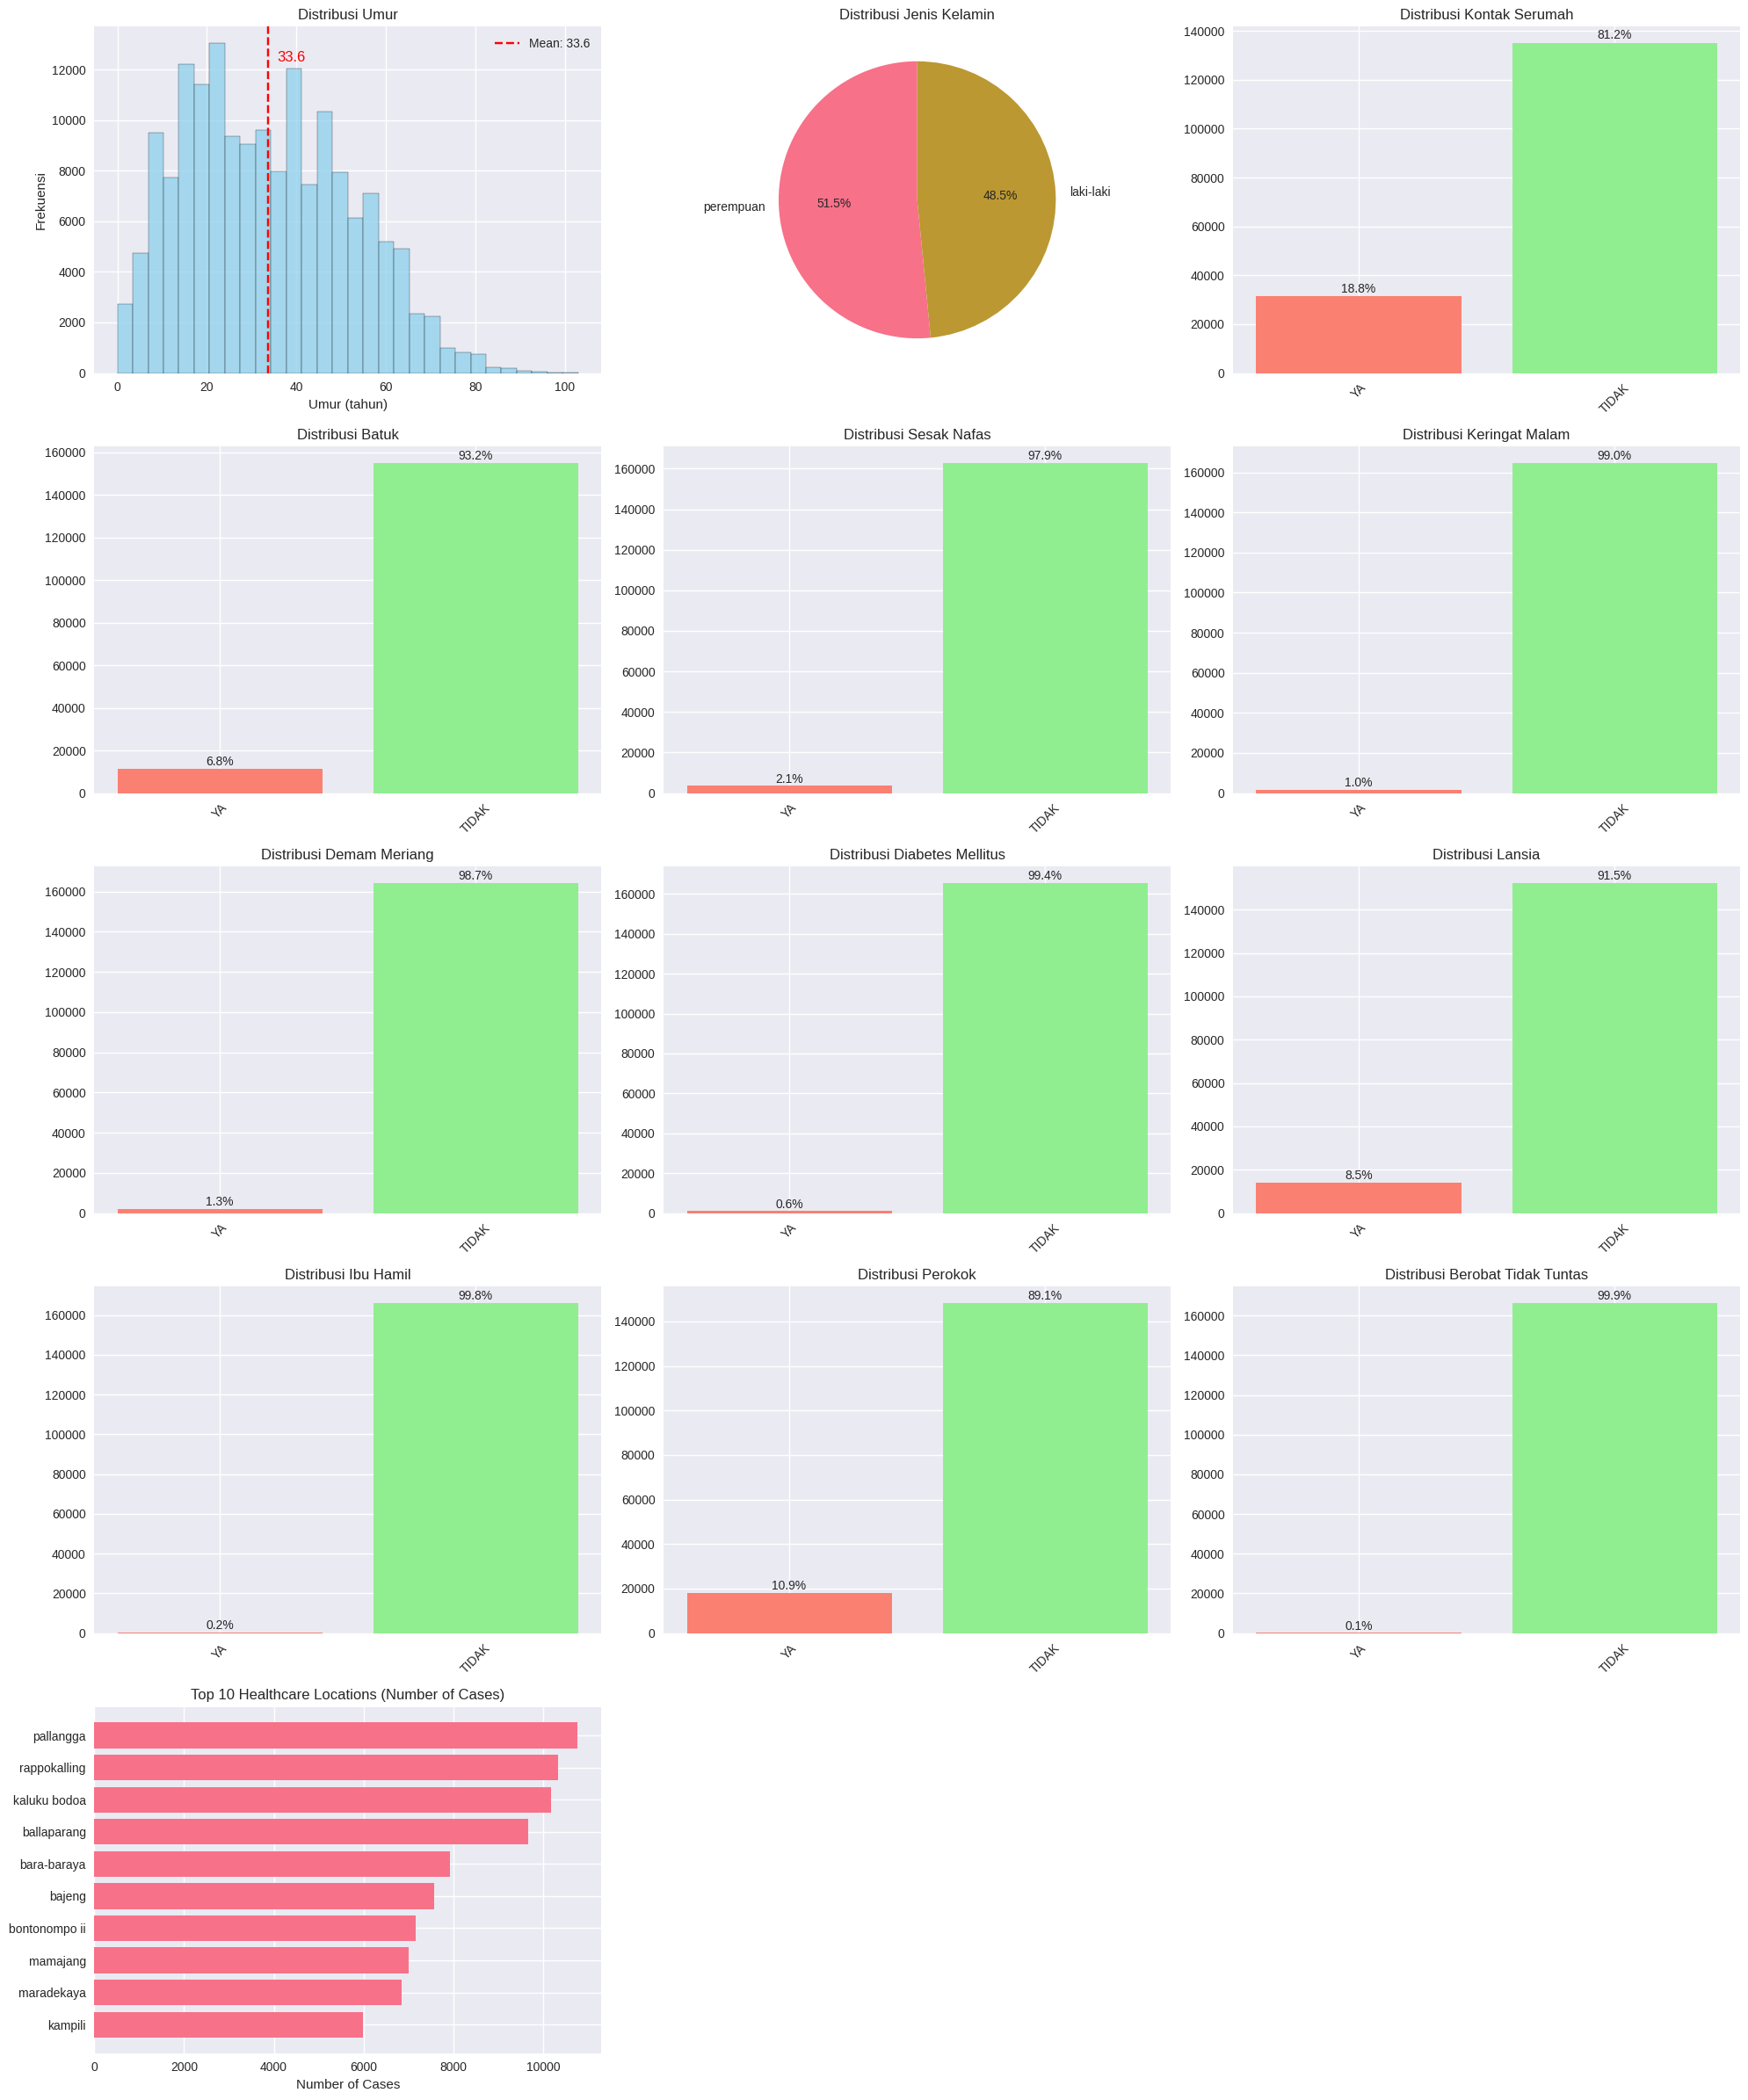


📊 Statistical Summary of Numeric Variables:
--------------------------------------------------
                umur
count  166265.000000
mean       33.637807
std        18.357152
min         0.000000
25%        19.000000
50%        32.000000
75%        48.000000
max       103.000000


In [65]:
# 4. Univariate Analysis
univariate_analysis(df_kontak_eda, binary_cols)


In [66]:
def plot_age_distribution(df, save_path=None):
    mean_umur = df['umur'].mean()

    plt.figure(figsize=(8, 6))
    plt.hist(df['umur'], bins=30, edgecolor='black')
    plt.axvline(mean_umur, linestyle='--', label=f'Rata-rata: {mean_umur:.1f}')

    plt.xlabel('Age (years)')
    plt.ylabel('Frequency')
    plt.title('Age Distribution of Tuberculosis')
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


### C.1.3 Bivariate Analysis


🔗 BIVARIATE ANALYSIS


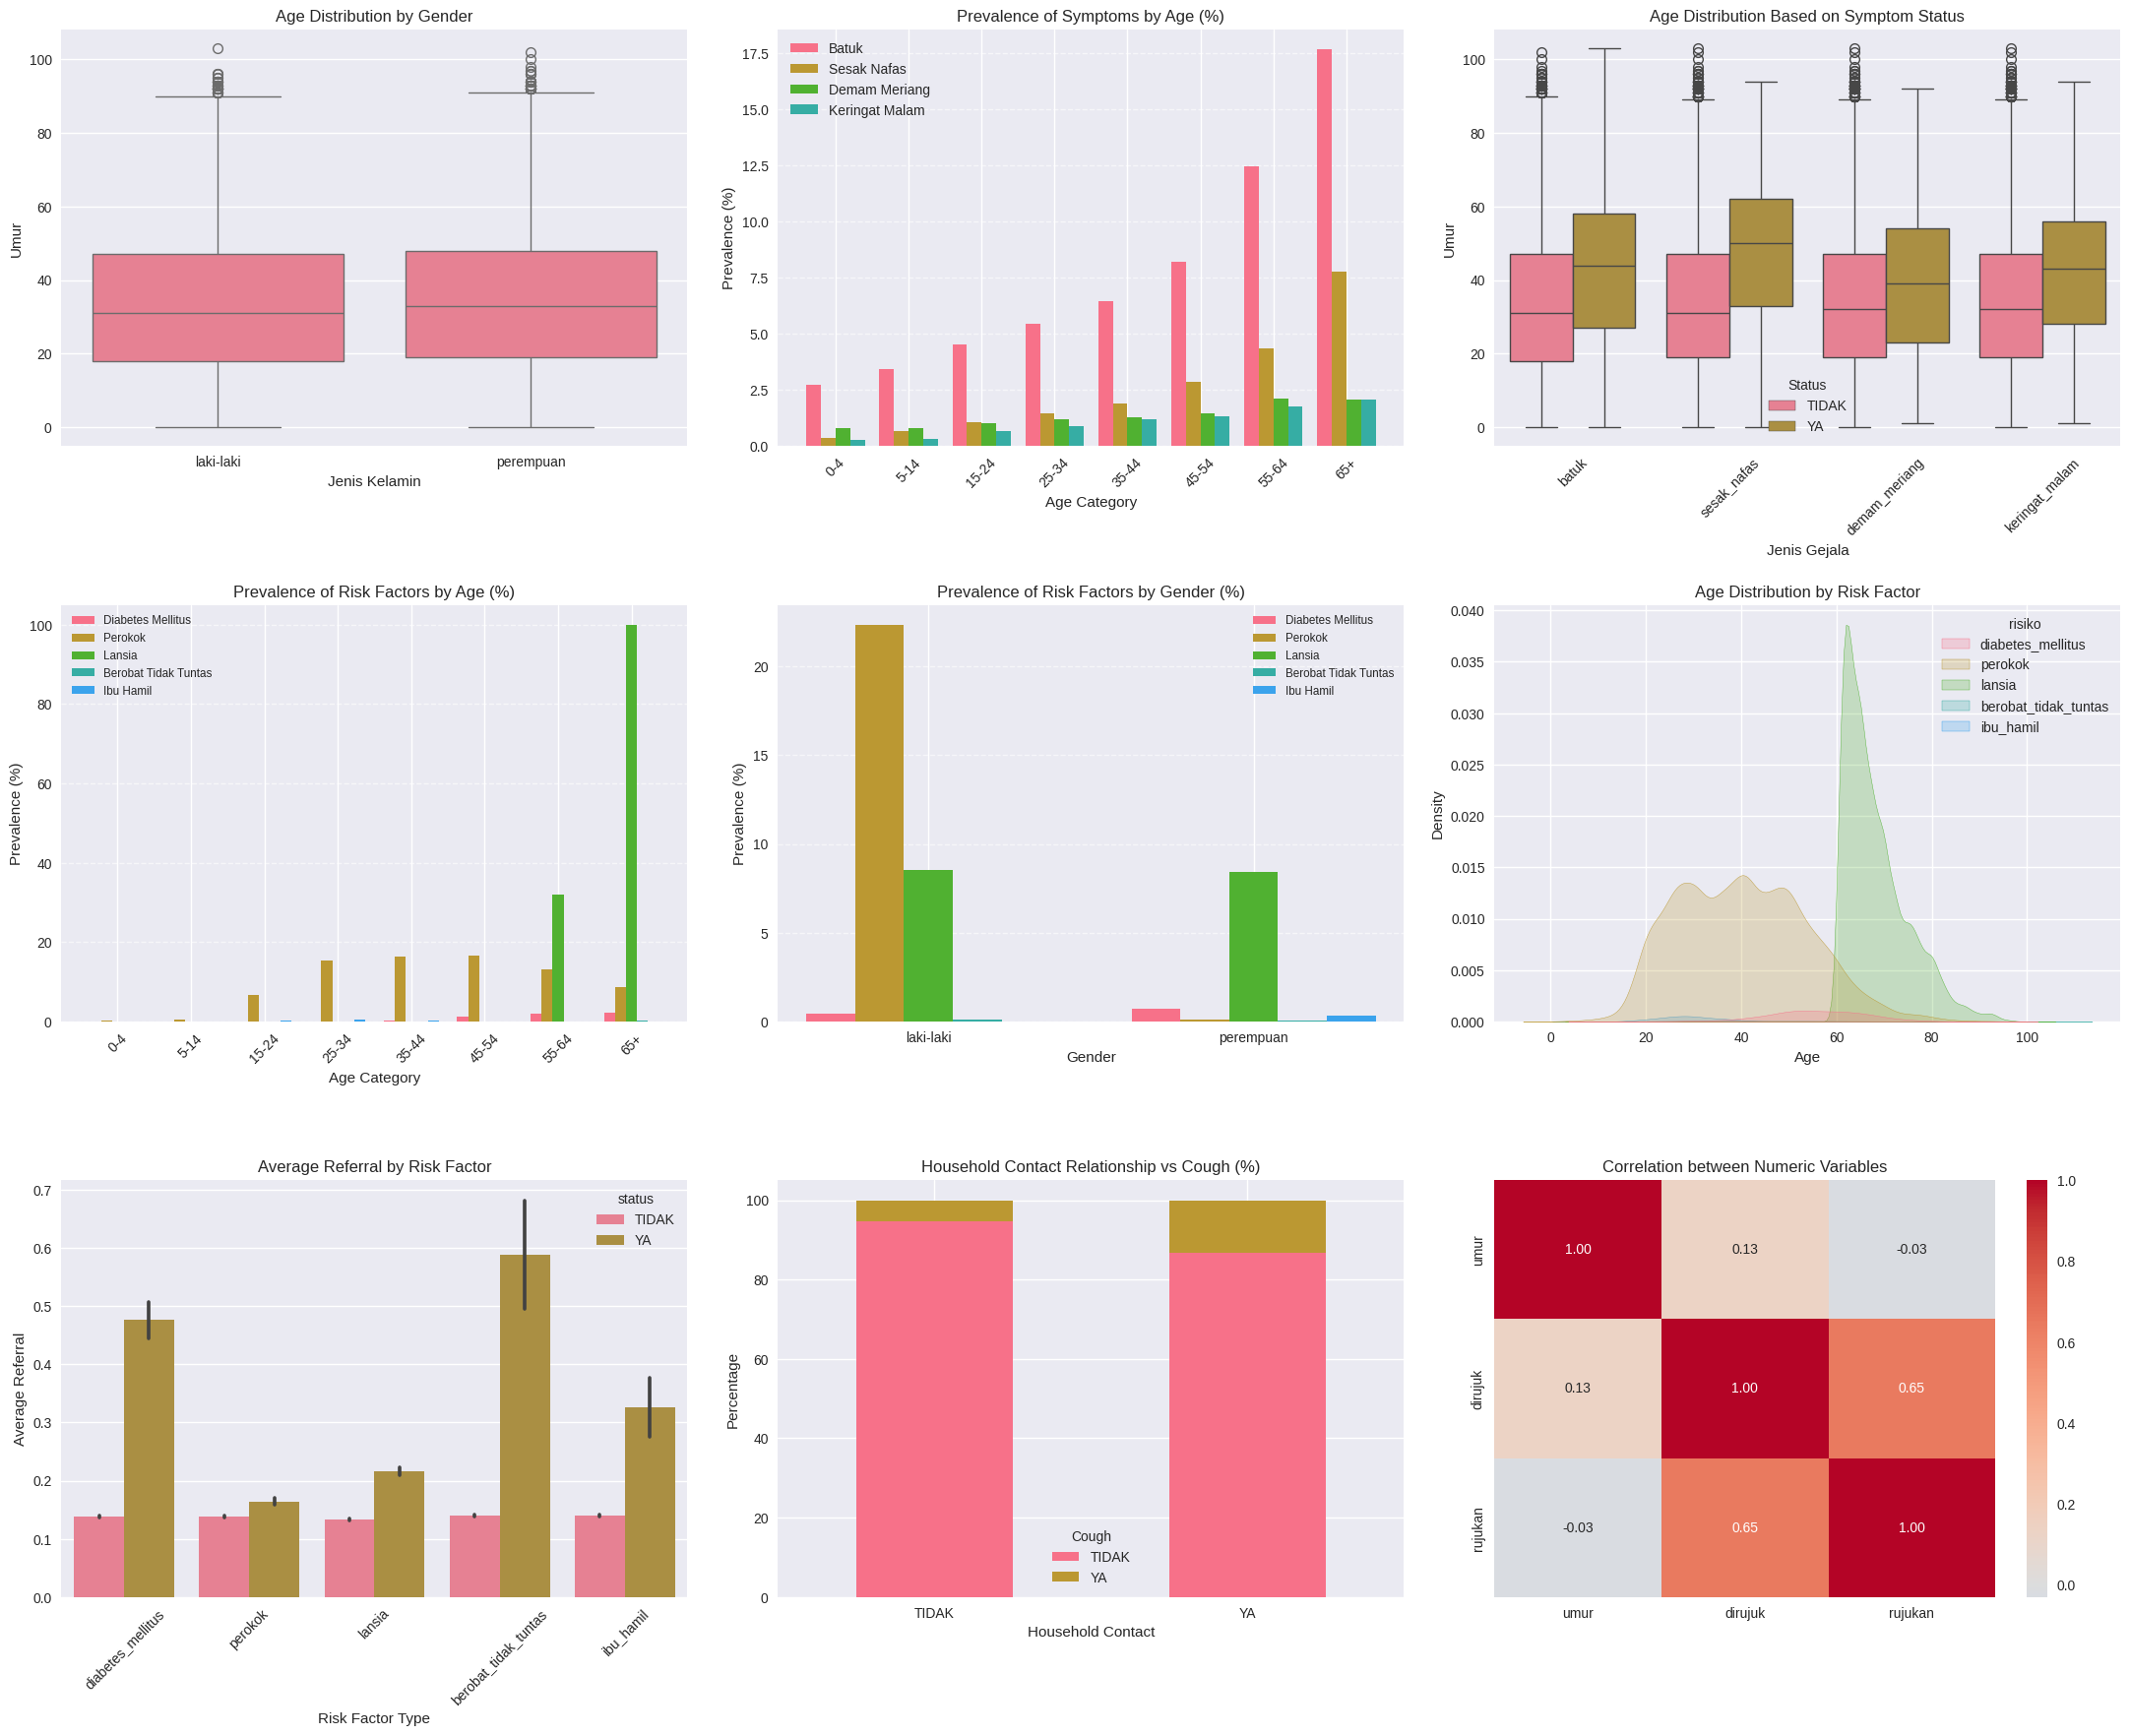

In [67]:
# 6. Bivariate Analysis
bivariate_analysis(df_kontak_eda)


### C.1.4 Temporal Analysis


⏰ TEMPORAL ANALYSIS


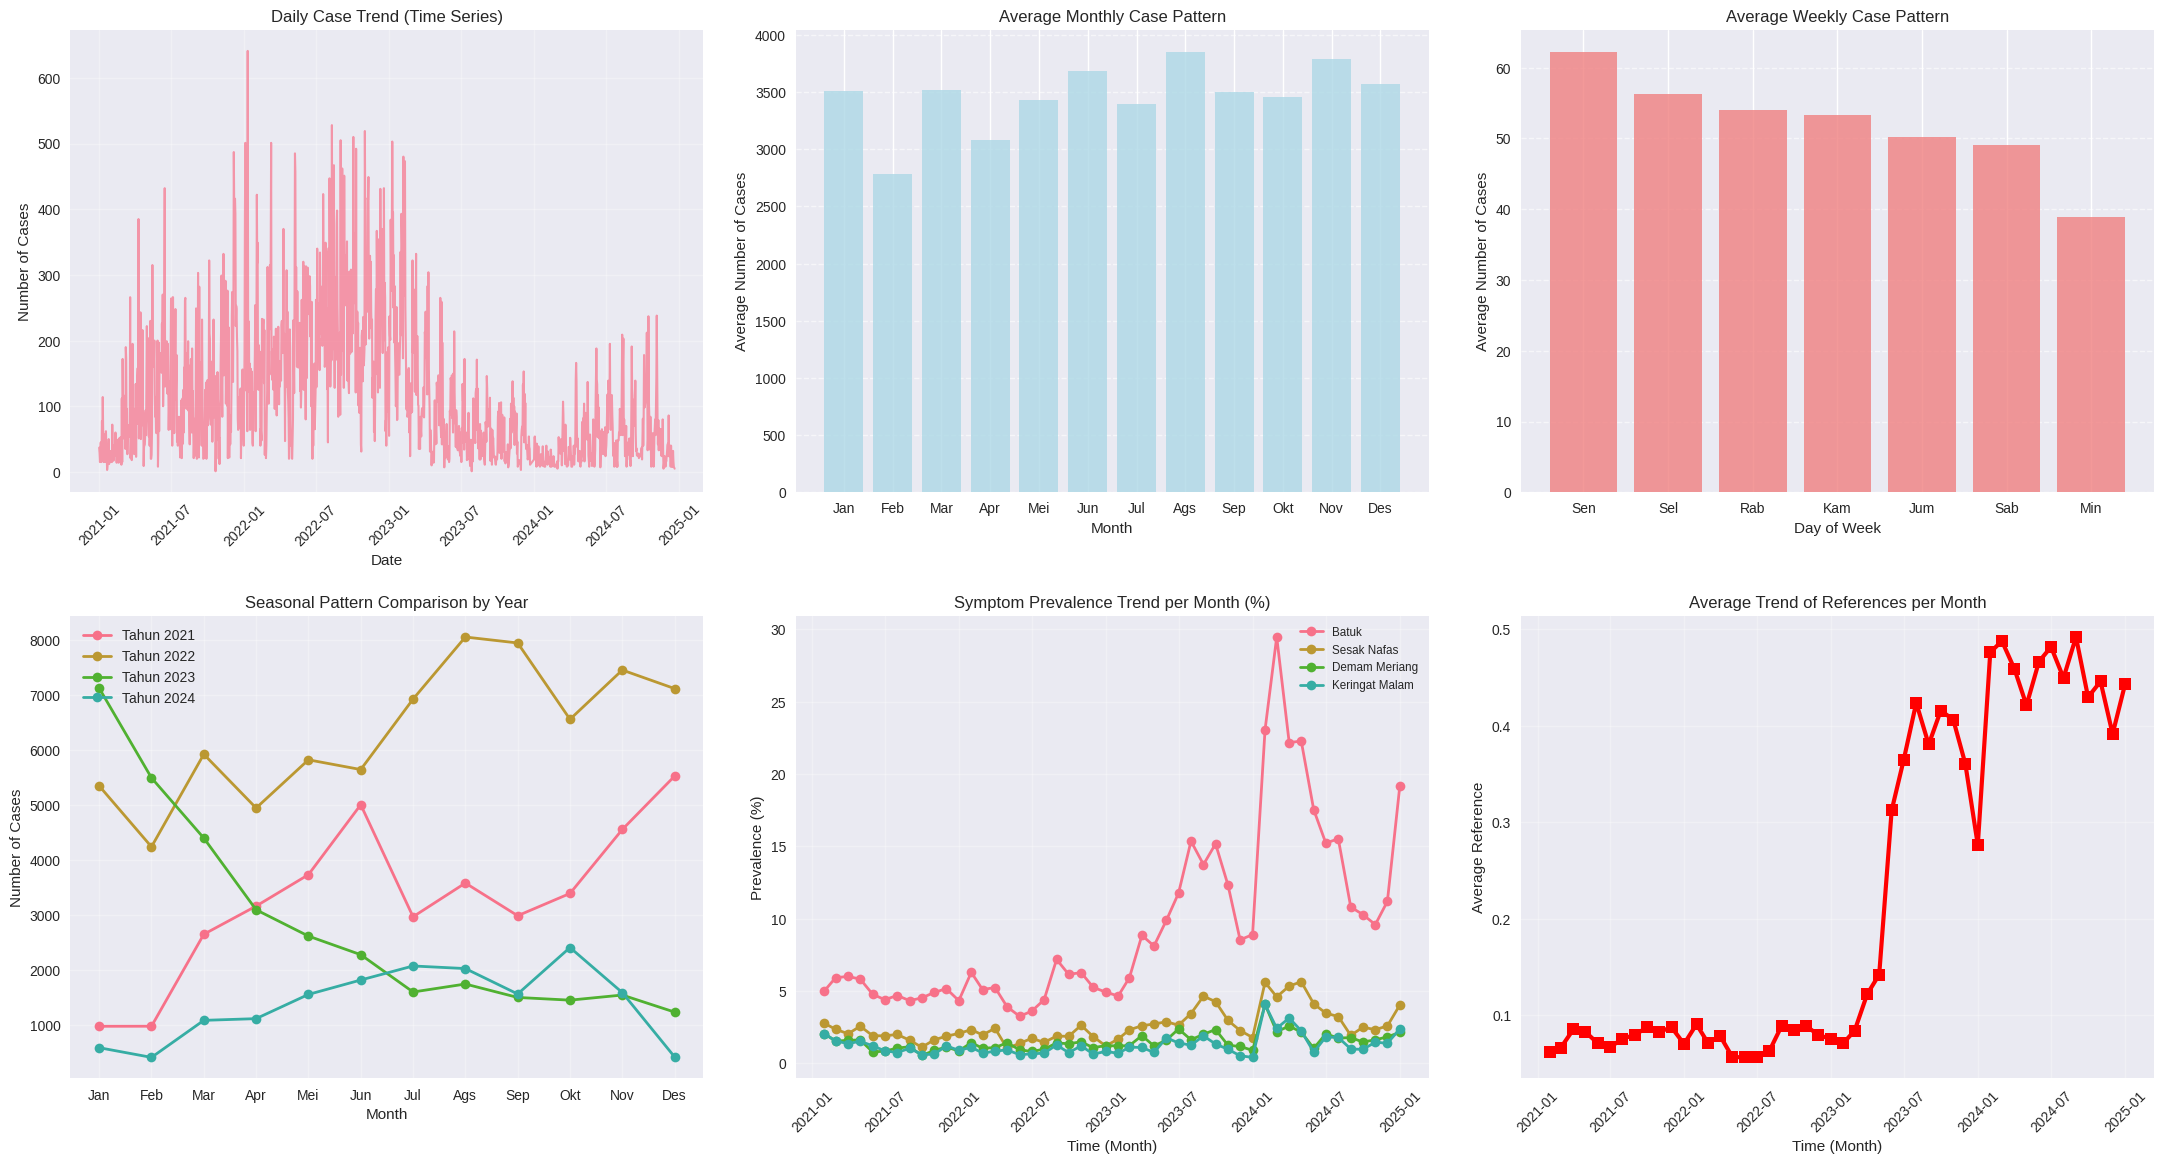


📊 Temporal Statistics:
------------------------------
📅 Data Time Range: 2021-01-01 to 2024-12-20
📊 Average cases per day: 120.3
🔝 Month with the highest average number of cases: Ags (3852.2 kasus/bulan)
🔻 Month with the lowest average cases: Feb (2781.8 kasus/bulan)


In [68]:
# 7. Temporal Analysis
temporal_analysis(df_kontak_eda)


### C.1.5 Geographic Analysis


🗺️  GEOGRAPHIC ANALYSIS (HEALTH CARE FACILITIES)


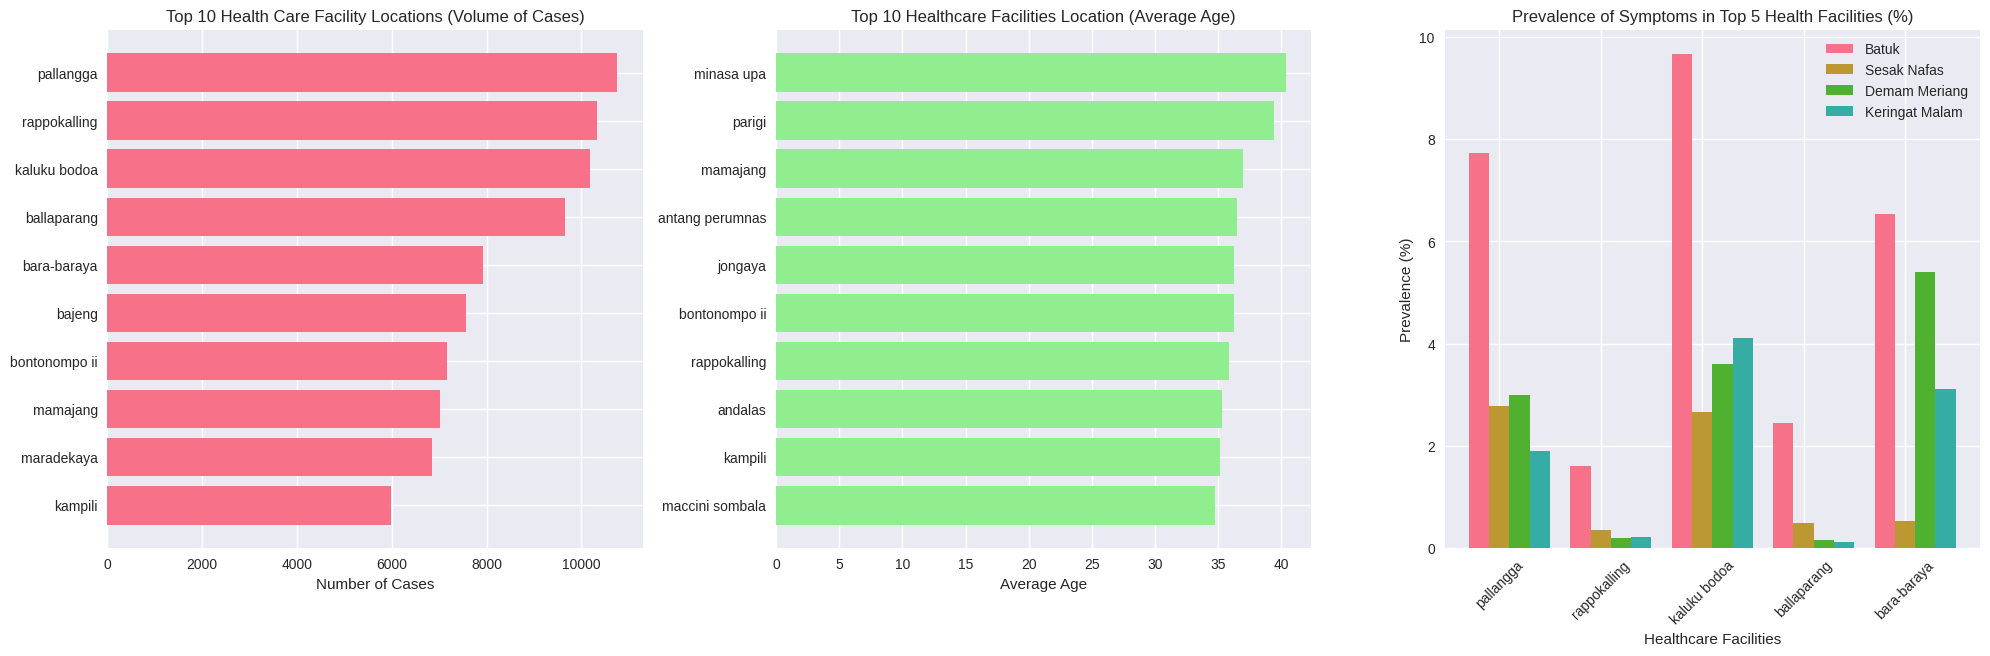


🏥 Healthcare Facility Statistics:
-----------------------------------
📊 Total Healthcare Facilities: 84
📈 Average cases per healthcare facility: 1979.3
🔝 Most healthcare facilities: pallangga (10,758 kasus)
📊 Top 5 healthcare facilities handle 29.4% of total cases


In [69]:
# 8. Geographic Analysis - Jalankan untuk melihat output geographic_analysis
geographic_analysis(df_kontak_eda)


# D. Data Preprocessing

In [70]:
df_kontak_updated = df_kontak_cleaned.copy()
df_terduga_key = df_terduga_cleaned.copy()

## D.1 Geocoding for df_kontak kecamatan

#### Get kecamatan value from Suspected TB Data Set

In [71]:
# STEP 1: CREATE THE INITIAL MAPPING FROM THE 'SUSPECTED TB DATA SET
mapping_fasyankes_kecamatan = (
    df_terduga_key[['fasyankes_lokasi', 'kecamatan']]
    .dropna()
    .drop_duplicates('fasyankes_lokasi') # Use drop_duplicates on the fasyankes_lokasi column
    .set_index('fasyankes_lokasi')['kecamatan']
    .to_dict()
)

mapping_fasyankes_kecamatan = {
    (str(k).strip().lower()): v
    for k, v in mapping_fasyankes_kecamatan.items()
}


# STEP 2: APPLY THE AUTOMATIC AND MANUAL MAPPINGS TO THE MAIN DATAFRAME
df_kontak_updated['kecamatan'] = (
    df_kontak_updated['fasyankes_lokasi'].astype(str).str.strip().str.lower()
    .map(mapping_fasyankes_kecamatan)
)

manual_mapping = {
    'sudiang raya': 'Biringkanaya',
    'pampang': 'Panakkukang',
    'barombong': 'Tamalate',
    'rs tk.ii pelamonia': 'Ujung Pandang',
    'minasa upa': 'Rappocini',
    'pertiwi': 'Mariso',
    'rs umum daerah daya kota makassar': 'Biringkanaya',
    'rs ibnu sina makassar': 'Panakkukang',
    'pattingalloang': 'Ujung Tanah',
    'mangasa': 'Tamalate',
    'rs kusta dr. tadjuddin chalid, mph': 'Tallo',
    'bira': 'Tamalanrea',
    'rs kepolisian bhayangkara': 'Mamajang',
    'rs mitra husada': 'Panakkukang',
    'cendrawasih': 'Mamajang',
    'rs islam faisal': 'Rappocini',
    'rs al jala ammari': 'Wajo',
    'rs primaya': 'Panakkukang',
    'rsup dr. wahidin sudirohusodo': 'Tamalanrea',
    'rs stella maris': 'Ujung Pandang',
    'rs umum daerah haji makassar': 'Tamalanrea',
    'rs hermina makassar': 'Panakkukang',
    'ibnu sina ybw umi': 'Makassar',
    'rs khusus daerah dadi': 'Mamajang',
    'makkasau': 'Rappocini',
    'tamalanrea': 'Tamalanrea',
    'rs grestelina': 'Panakkukang',
    'rs siloam makassar': 'Mariso',
    'tabaringan': 'Ujung Tanah',
    'pkm daya': 'Biringkanaya',
    'rs umum sandi karsa makassar': 'Tamalate',
}

# Fill NaN values in the 'kecamatan' column using the results from the manual_mapping
key_for_manual_mapping = df_kontak_updated['fasyankes_lokasi'].str.strip().str.lower()
df_kontak_updated['kecamatan'] = df_kontak_updated['kecamatan'].fillna(key_for_manual_mapping.map(manual_mapping))


# STEP 3: CENTRALIZED CLEANING (TYPOS AND CAPITALIZATION)
peta_koreksi_lengkap = {
    'makasar': 'Makassar',
    'panakukkang': 'Panakkukang',
    'palangga': 'Pallangga',
    'somba upu': 'Somba Opu',
    'barombong': 'Tamalate'
}

df_kontak_updated['kecamatan'] = (
    df_kontak_updated['kecamatan'].str.lower()
    .replace(peta_koreksi_lengkap)
    .str.title()
)

# STEP 4: ADD THE REGENCY/CITY AND FINALIZE
# Lists of correctly spelled 'kecamatan'
kecamatan_makassar = [
    'Makassar', 'Panakkukang', 'Mamajang', 'Tamalate', 'Manggala',
    'Biringkanaya', 'Bontoala', 'Tallo', 'Wajo', 'Tamalanrea',
    'Rappocini', 'Mariso', 'Ujung Pandang', 'Ujung Tanah'
]
kecamatan_gowa = [
    'Pallangga', 'Parangloe', 'Somba Opu', 'Bajeng', 'Bontonompo Selatan',
    'Bajeng Barat', 'Bontonompo', 'Bontomarannu', 'Manuju', 'Biringbulu',
    'Parigi'
]

# Function to add the regency/city name
def tambahkan_kabupaten_kota(nama_kecamatan):
    if nama_kecamatan in kecamatan_makassar:
        return f"{nama_kecamatan}, Kota Makassar"
    elif nama_kecamatan in kecamatan_gowa:
        return f"{nama_kecamatan}, Kabupaten Gowa"
    else:
        return nama_kecamatan

# Apply the function to the cleaned 'kecamatan' column
df_kontak_updated['alamat'] = df_kontak_updated['kecamatan'].apply(tambahkan_kabupaten_kota)

# Drop the now-redundant 'kecamatan' column
df_kontak_updated.drop(columns=['kecamatan'], inplace=True)


# Display the final results for verification
print(df_kontak_updated[['fasyankes_lokasi', 'alamat']].head())

# Check if there are any remaining empty values
print(f"\nNumber of rows without an address: {df_kontak_updated['alamat'].isna().sum()}\n")
print(df_kontak_updated['alamat'].value_counts())

  fasyankes_lokasi                alamat
0     kaluku bodoa  Tallo, Kota Makassar
1     kaluku bodoa  Tallo, Kota Makassar
2     kaluku bodoa  Tallo, Kota Makassar
3     kaluku bodoa  Tallo, Kota Makassar
4     kaluku bodoa  Tallo, Kota Makassar

Number of rows without an address: 0

alamat
Tallo, Kota Makassar                  25857
Makassar, Kota Makassar               18618
Pallangga, Kabupaten Gowa             16753
Tamalate, Kota Makassar               16400
Manggala, Kota Makassar               11904
Rappocini, Kota Makassar              10579
Bajeng, Kabupaten Gowa                 9760
Somba Opu, Kabupaten Gowa              7499
Mamajang, Kota Makassar                7306
Bontonompo, Kabupaten Gowa             7164
Bontoala, Kota Makassar                5668
Biringkanaya, Kota Makassar            5553
Bajeng Barat, Kabupaten Gowa           5455
Panakkukang, Kota Makassar             5431
Bontonompo Selatan, Kabupaten Gowa     4421
Wajo, Kota Makassar                    2965
Bont

In [72]:
display(df_kontak_updated.info())
display(df_kontak_updated.head())

<class 'pandas.core.frame.DataFrame'>
Index: 166265 entries, 0 to 166811
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tanggal_kegiatan      166265 non-null  datetime64[ns]
 1   fasyankes_lokasi      166265 non-null  object        
 2   nama_kontak           166265 non-null  object        
 3   jenis_kelamin         166265 non-null  object        
 4   umur                  166265 non-null  int64         
 5   kontak_serumah        166265 non-null  object        
 6   batuk                 166265 non-null  object        
 7   sesak_nafas           166265 non-null  object        
 8   keringat_malam        166265 non-null  object        
 9   demam_meriang         166265 non-null  object        
 10  diabetes_mellitus     166265 non-null  object        
 11  lansia                166265 non-null  object        
 12  ibu_hamil             166265 non-null  object        
 13  pero

None

,tanggal_kegiatan,fasyankes_lokasi,nama_kontak,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,rujukan,ssr,alamat
0,2021-06-23,kaluku bodoa,dg colleng,laki-laki,70,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,kota makassar,"Tallo, Kota Makassar"
1,2021-06-23,kaluku bodoa,mansia,perempuan,67,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,0,kota makassar,"Tallo, Kota Makassar"
2,2021-06-23,kaluku bodoa,risal,laki-laki,38,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,0,kota makassar,"Tallo, Kota Makassar"
3,2021-06-23,kaluku bodoa,irfan,laki-laki,35,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,0,kota makassar,"Tallo, Kota Makassar"
4,2021-06-23,kaluku bodoa,risna,perempuan,31,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,0,kota makassar,"Tallo, Kota Makassar"


#### Geocoding

In [73]:
# GEOCODING FUNCTION
def get_lat_lng(address, api_key):
    """Gets the latitude and longitude for an address using the Google Geocoding API."""
    base_url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {"address": address, "key": api_key}

    try:
        response = requests.get(base_url, params=params)
        if response.status_code == 200:
            results = response.json().get("results")
            if results:
                location = results[0]["geometry"]["location"]
                return location["lat"], location["lng"]
    except requests.exceptions.RequestException as e:
        print(f"A connection error occurred: {e}")

    return None, None


# GEOCODING PROCESS

# API Key is available in the environment
API_KEY = userdata.get('GEOCODING_API_KEY')

if not API_KEY:
    print("\nAPI Key not found. Geocoding process cancelled.")
else:
    # Get unique locations from the 'alamat' column
    unique_locations = df_kontak_updated['alamat'].unique()
    print(f"\nFound {len(unique_locations)} unique locations to geocode.")

    geocoding_cache = {}

    # Perform geocoding only for the unique locations
    for address in unique_locations:
        # Handle potential NaN values in the address column
        if pd.isna(address):
            continue

        print(f"Fetching coordinates for: {address}...")

        # Call the geocoding function and store the result in the cache
        lat, lng = get_lat_lng(address, API_KEY)
        geocoding_cache[address] = (lat, lng)

    print("\nGeocoding for unique locations complete.")

    # Map the geocoding results from the cache back to the main DataFrame
    mapped_coords = df_kontak_updated['alamat'].map(geocoding_cache)

    # Create new latitude and longitude columns from the mapped results
    df_kontak_updated['latitude'] = mapped_coords.str[0]
    df_kontak_updated['longitude'] = mapped_coords.str[1]



Found 25 unique locations to geocode.
Fetching coordinates for: Tallo, Kota Makassar...
Fetching coordinates for: Manggala, Kota Makassar...
Fetching coordinates for: Bontoala, Kota Makassar...
Fetching coordinates for: Mamajang, Kota Makassar...
Fetching coordinates for: Tamalate, Kota Makassar...
Fetching coordinates for: Makassar, Kota Makassar...
Fetching coordinates for: Panakkukang, Kota Makassar...
Fetching coordinates for: Rappocini, Kota Makassar...
Fetching coordinates for: Biringkanaya, Kota Makassar...
Fetching coordinates for: Tamalanrea, Kota Makassar...
Fetching coordinates for: Wajo, Kota Makassar...
Fetching coordinates for: Parigi, Kabupaten Gowa...
Fetching coordinates for: Bajeng Barat, Kabupaten Gowa...
Fetching coordinates for: Bontonompo Selatan, Kabupaten Gowa...
Fetching coordinates for: Bontonompo, Kabupaten Gowa...
Fetching coordinates for: Somba Opu, Kabupaten Gowa...
Fetching coordinates for: Pallangga, Kabupaten Gowa...
Fetching coordinates for: Manuju, K

In [74]:
cols_to_drop = [
  'nama_kontak',
  'rujukan',
  'ssr'

]

df_kontak_updated.drop(columns=cols_to_drop, inplace=True)
df_kontak_updated.sample(10)

,tanggal_kegiatan,fasyankes_lokasi,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,alamat,latitude,longitude
69599,2022-10-31,kaluku bodoa,laki-laki,41,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,"Tallo, Kota Makassar",None,None
2317,2021-06-21,karuwisi,perempuan,59,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,0,"Panakkukang, Kota Makassar",None,None
12259,2021-12-01,batua,laki-laki,45,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Manggala, Kota Makassar",None,None
158858,2023-06-23,samata,perempuan,12,TIDAK,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,1,"Somba Opu, Kabupaten Gowa",None,None
126301,2023-01-11,malimongan baru,laki-laki,38,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Bontoala, Kota Makassar",None,None
115339,2023-05-10,malimongan baru,perempuan,21,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Bontoala, Kota Makassar",None,None
117621,2023-04-12,paccerakkang,laki-laki,22,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Biringkanaya, Kota Makassar",None,None
158030,2023-08-18,samata,perempuan,21,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Somba Opu, Kabupaten Gowa",None,None
142266,2024-08-21,kaluku bodoa,perempuan,61,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None
40226,2022-07-23,ballaparang,perempuan,3,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Rappocini, Kota Makassar",None,None


In [75]:
# download df_kontak_updated to .csv
download_choice = input("Do you want to download the df_kontak_updated.csv? (y/n): ").lower()

if download_choice == 'y':
    df_kontak_updated.to_csv('df_kontak_updated.csv', index=False)
    print("df_kontak_updated.csv has been downloaded.")
else:
    print("Download skipped.")

Do you want to download the df_kontak_updated.csv? (y/n): y
df_kontak_updated.csv has been downloaded.


Original Columns are:
- `umur`
- `jenis_kelamin`
- `kontak_serumah`
- `batuk`
- `sesak_nafas`
- `keringat_malam`
- `demam_meriang`
- `perokok`
- `lansia`
- `ibu_hamil`
- `diabetes_mellitus`
- `berobat_tidak_tuntas`

## D.3 Tuberculosis Contact Investigation Data Set [**Area-Based**]

**Transform df_kontak_updated.csv into a format by sub-district (kecamatan)**

In [76]:
df_kontak_aggregate = df_kontak_updated.copy()
df_kontak_aggregate.head()

,tanggal_kegiatan,fasyankes_lokasi,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,alamat,latitude,longitude
0,2021-06-23,kaluku bodoa,laki-laki,70,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None
1,2021-06-23,kaluku bodoa,perempuan,67,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None
2,2021-06-23,kaluku bodoa,laki-laki,38,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,"Tallo, Kota Makassar",None,None
3,2021-06-23,kaluku bodoa,laki-laki,35,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,"Tallo, Kota Makassar",None,None
4,2021-06-23,kaluku bodoa,perempuan,31,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None


In [77]:
df_kontak_aggregate.shape

(166265, 18)

### D.3.1 Data Aggregation (All)

#### Agregation

In [78]:
# Defining Column Groups
# Numeric columns for which we will calculate the average (mean)
kolom_numerik_mean = ['umur']

kolom_lokasi = ['latitude', 'longitude']

# Binary columns ('YA'/'TIDAK') that repreent symptoms or risk factors
kolom_biner = [
    'kontak_serumah', 'batuk', 'sesak_nafas', 'keringat_malam',
    'demam_meriang', 'diabetes_mellitus', 'lansia', 'ibu_hamil',
    'perokok', 'berobat_tidak_tuntas'
]

print(f"Column for Group: {'alamat'}")
print(f"Numeric Column (Mean): {kolom_numerik_mean}")
print(f"Location Column (First): {kolom_lokasi}")
print(f"Binary Column (Count 'YA'): {kolom_biner}")

Column for Group: alamat
Numeric Column (Mean): ['umur']
Location Column (First): ['latitude', 'longitude']
Binary Column (Count 'YA'): ['kontak_serumah', 'batuk', 'sesak_nafas', 'keringat_malam', 'demam_meriang', 'diabetes_mellitus', 'lansia', 'ibu_hamil', 'perokok', 'berobat_tidak_tuntas']


In [79]:
# Data Aggregation
# =========================================================================
# 1. Total contacts/cases in each sub-district
# 2. Average age
# 3. Latitude and longitude coordinates

# Perform groupby and aggregation using more modern syntax
df_kontak_perkecamatan = df_kontak_aggregate.groupby('alamat').agg(
    rata_rata_umur=('umur', 'mean'),
    total_kontak=('umur', 'count'),
    total_dirujuk=('dirujuk', 'sum'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
)

df_kontak_perkecamatan

,rata_rata_umur,total_kontak,total_dirujuk,latitude,longitude
alamat,,,,,
"Bajeng Barat, Kabupaten Gowa",34.393767,5455,678,None,None
"Bajeng, Kabupaten Gowa",33.424795,9760,1154,None,None
"Biringbulu, Kabupaten Gowa",39.500000,32,12,None,None
"Biringkanaya, Kota Makassar",31.614983,5553,139,None,None
"Bontoala, Kota Makassar",34.574277,5668,44,None,None
"Bontomarannu, Kabupaten Gowa",32.729827,1388,204,None,None
"Bontonompo Selatan, Kabupaten Gowa",33.252658,4421,350,None,None
"Bontonompo, Kabupaten Gowa",36.250558,7164,1179,None,None
"Makassar, Kota Makassar",32.863412,18618,689,None,None


### D.3.2 Data Transformation

In [80]:
# Adding the Number of Unique Healthcare Facilities
# ===============================================

# Calculate the number of unique healthcare facilities for each address
jumlah_fasyankes_unik = df_kontak_aggregate.groupby('alamat')['fasyankes_lokasi'].nunique()

df_kontak_perkecamatan = df_kontak_perkecamatan.join(jumlah_fasyankes_unik.rename('jumlah_fasyankes_unik'))

print("\n--- Aggregation Results After Adding the Number of Unique Healthcare Facilities ---")
df_kontak_perkecamatan


--- Aggregation Results After Adding the Number of Unique Healthcare Facilities ---


,rata_rata_umur,total_kontak,total_dirujuk,latitude,longitude,jumlah_fasyankes_unik
alamat,,,,,,
"Bajeng Barat, Kabupaten Gowa",34.393767,5455,678,None,None,1
"Bajeng, Kabupaten Gowa",33.424795,9760,1154,None,None,2
"Biringbulu, Kabupaten Gowa",39.500000,32,12,None,None,1
"Biringkanaya, Kota Makassar",31.614983,5553,139,None,None,6
"Bontoala, Kota Makassar",34.574277,5668,44,None,None,2
"Bontomarannu, Kabupaten Gowa",32.729827,1388,204,None,None,1
"Bontonompo Selatan, Kabupaten Gowa",33.252658,4421,350,None,None,1
"Bontonompo, Kabupaten Gowa",36.250558,7164,1179,None,None,1
"Makassar, Kota Makassar",32.863412,18618,689,None,None,4


In [81]:
# Binary Feature Aggregation (Symptoms & Risk Factors)
# ====================================================

# Copy relevant columns for processing
df_biner_proc = df_kontak_aggregate[['alamat'] + kolom_biner].copy()

# Chnage 'YA'/'TIDAK' values to 1/0
for col in kolom_biner:
    df_biner_proc[col] = df_biner_proc[col].map({'YA': 1, 'TIDAK': 0}).fillna(0)

# Group by 'alamat' and sum to get the total 'YA'
agregat_biner = df_biner_proc.groupby('alamat').sum()

# Combine results Binary aggregation to the main DataFrame
df_kontak_perkecamatan = df_kontak_perkecamatan.join(agregat_biner)

print("\n--- Aggregation Results After Adding Binary Features ---")
df_kontak_perkecamatan


--- Aggregation Results After Adding Binary Features ---


,rata_rata_umur,total_kontak,total_dirujuk,latitude,longitude,jumlah_fasyankes_unik,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas
alamat,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",34.393767,5455,678,None,None,1,1056,661,308,21,3,7,624,0,117,1
"Bajeng, Kabupaten Gowa",33.424795,9760,1154,None,None,2,1792,1155,491,49,14,24,938,8,573,2
"Biringbulu, Kabupaten Gowa",39.500000,32,12,None,None,1,7,12,0,0,0,0,2,0,9,0
"Biringkanaya, Kota Makassar",31.614983,5553,139,None,None,6,1388,152,27,4,25,6,362,7,336,1
"Bontoala, Kota Makassar",34.574277,5668,44,None,None,2,1187,47,9,7,14,6,520,1,621,2
"Bontomarannu, Kabupaten Gowa",32.729827,1388,204,None,None,1,296,205,12,4,3,0,117,0,26,0
"Bontonompo Selatan, Kabupaten Gowa",33.252658,4421,350,None,None,1,741,347,61,29,22,27,486,19,526,6
"Bontonompo, Kabupaten Gowa",36.250558,7164,1179,None,None,1,1484,1177,808,80,65,38,962,5,354,6
"Makassar, Kota Makassar",32.863412,18618,689,None,None,4,3570,739,89,275,445,22,1298,2,1002,7


In [82]:
# Aggregate the 'jenis_kelamin' Feature
# ===================================================

# Create a frequency table (cross-tabulation) between address and gender
agregat_gender = pd.crosstab(df_kontak_aggregate['alamat'], df_kontak_aggregate['jenis_kelamin'])

# Combine the gender count results into the main DataFrame
df_kontak_perkecamatan = df_kontak_perkecamatan.join(agregat_gender)

print("\n--- Aggregation Results After Adding Gender ---")
df_kontak_perkecamatan


--- Aggregation Results After Adding Gender ---


,rata_rata_umur,total_kontak,total_dirujuk,latitude,longitude,jumlah_fasyankes_unik,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,laki-laki,perempuan
alamat,,,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",34.393767,5455,678,None,None,1,1056,661,308,21,3,7,624,0,117,1,2664,2791
"Bajeng, Kabupaten Gowa",33.424795,9760,1154,None,None,2,1792,1155,491,49,14,24,938,8,573,2,4697,5063
"Biringbulu, Kabupaten Gowa",39.500000,32,12,None,None,1,7,12,0,0,0,0,2,0,9,0,14,18
"Biringkanaya, Kota Makassar",31.614983,5553,139,None,None,6,1388,152,27,4,25,6,362,7,336,1,2747,2806
"Bontoala, Kota Makassar",34.574277,5668,44,None,None,2,1187,47,9,7,14,6,520,1,621,2,2772,2896
"Bontomarannu, Kabupaten Gowa",32.729827,1388,204,None,None,1,296,205,12,4,3,0,117,0,26,0,658,730
"Bontonompo Selatan, Kabupaten Gowa",33.252658,4421,350,None,None,1,741,347,61,29,22,27,486,19,526,6,2112,2309
"Bontonompo, Kabupaten Gowa",36.250558,7164,1179,None,None,1,1484,1177,808,80,65,38,962,5,354,6,3335,3829
"Makassar, Kota Makassar",32.863412,18618,689,None,None,4,3570,739,89,275,445,22,1298,2,1002,7,9257,9361


In [83]:
df_kontak_perkecamatan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, Bajeng Barat, Kabupaten Gowa to Wajo, Kota Makassar
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rata_rata_umur         25 non-null     float64
 1   total_kontak           25 non-null     int64  
 2   total_dirujuk          25 non-null     int64  
 3   latitude               0 non-null      object 
 4   longitude              0 non-null      object 
 5   jumlah_fasyankes_unik  25 non-null     int64  
 6   kontak_serumah         25 non-null     int64  
 7   batuk                  25 non-null     int64  
 8   sesak_nafas            25 non-null     int64  
 9   keringat_malam         25 non-null     int64  
 10  demam_meriang          25 non-null     int64  
 11  diabetes_mellitus      25 non-null     int64  
 12  lansia                 25 non-null     int64  
 13  ibu_hamil              25 non-null     int64  
 14  perokok              

In [84]:
df_kontak_perkecamatan = df_kontak_perkecamatan.astype(float)

# 1. Define the desired column order manually
urutan_kolom_baru = [
    'rata_rata_umur',
    'total_kontak',
    'total_dirujuk',
    'laki-laki',
    'perempuan',
    'kontak_serumah',
    'batuk',
    'sesak_nafas',
    'keringat_malam',
    'demam_meriang',
    'diabetes_mellitus',
    'lansia',
    'ibu_hamil',
    'perokok',
    'berobat_tidak_tuntas',
    'jumlah_fasyankes_unik',
    'latitude',
    'longitude'
]

df_kontak_perkecamatan = df_kontak_perkecamatan[urutan_kolom_baru]

# Display the final DataFrame
pd.set_option('display.max_columns', None)
display(df_kontak_perkecamatan)
display(df_kontak_perkecamatan.info())

,rata_rata_umur,total_kontak,total_dirujuk,laki-laki,perempuan,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,jumlah_fasyankes_unik,latitude,longitude
alamat,,,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",34.393767,5455.0,678.0,2664.0,2791.0,1056.0,661.0,308.0,21.0,3.0,7.0,624.0,0.0,117.0,1.0,1.0,NaN,NaN
"Bajeng, Kabupaten Gowa",33.424795,9760.0,1154.0,4697.0,5063.0,1792.0,1155.0,491.0,49.0,14.0,24.0,938.0,8.0,573.0,2.0,2.0,NaN,NaN
"Biringbulu, Kabupaten Gowa",39.500000,32.0,12.0,14.0,18.0,7.0,12.0,0.0,0.0,0.0,0.0,2.0,0.0,9.0,0.0,1.0,NaN,NaN
"Biringkanaya, Kota Makassar",31.614983,5553.0,139.0,2747.0,2806.0,1388.0,152.0,27.0,4.0,25.0,6.0,362.0,7.0,336.0,1.0,6.0,NaN,NaN
"Bontoala, Kota Makassar",34.574277,5668.0,44.0,2772.0,2896.0,1187.0,47.0,9.0,7.0,14.0,6.0,520.0,1.0,621.0,2.0,2.0,NaN,NaN
"Bontomarannu, Kabupaten Gowa",32.729827,1388.0,204.0,658.0,730.0,296.0,205.0,12.0,4.0,3.0,0.0,117.0,0.0,26.0,0.0,1.0,NaN,NaN
"Bontonompo Selatan, Kabupaten Gowa",33.252658,4421.0,350.0,2112.0,2309.0,741.0,347.0,61.0,29.0,22.0,27.0,486.0,19.0,526.0,6.0,1.0,NaN,NaN
"Bontonompo, Kabupaten Gowa",36.250558,7164.0,1179.0,3335.0,3829.0,1484.0,1177.0,808.0,80.0,65.0,38.0,962.0,5.0,354.0,6.0,1.0,NaN,NaN
"Makassar, Kota Makassar",32.863412,18618.0,689.0,9257.0,9361.0,3570.0,739.0,89.0,275.0,445.0,22.0,1298.0,2.0,1002.0,7.0,4.0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, Bajeng Barat, Kabupaten Gowa to Wajo, Kota Makassar
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rata_rata_umur         25 non-null     float64
 1   total_kontak           25 non-null     float64
 2   total_dirujuk          25 non-null     float64
 3   laki-laki              25 non-null     float64
 4   perempuan              25 non-null     float64
 5   kontak_serumah         25 non-null     float64
 6   batuk                  25 non-null     float64
 7   sesak_nafas            25 non-null     float64
 8   keringat_malam         25 non-null     float64
 9   demam_meriang          25 non-null     float64
 10  diabetes_mellitus      25 non-null     float64
 11  lansia                 25 non-null     float64
 12  ibu_hamil              25 non-null     float64
 13  perokok                25 non-null     float64
 14  berobat_tidak_tuntas 

None

In [85]:
# Download df_kontak_updated: df_kontak_perkecamatan with necessary columns before encoding, normalization, and transformation
download_choice = input("Do you want to download the df_kontak_perkecamatan.csv? (y/n): ").lower()

if download_choice == 'y':
    df_kontak_perkecamatan.to_csv('df_kontak_perkecamatan.csv')
    print("df_kontak_perkecamatan.csv has been downloaded.")
else:
    print("Download skipped.")

Do you want to download the df_kontak_perkecamatan.csv? (y/n): y
df_kontak_perkecamatan.csv has been downloaded.


### Data Aggregation (per Year)

In [86]:
df_kontak_aggregate_per_year = df_kontak_updated.copy()
df_kontak_aggregate_per_year.head()

,tanggal_kegiatan,fasyankes_lokasi,jenis_kelamin,umur,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,dirujuk,alamat,latitude,longitude
0,2021-06-23,kaluku bodoa,laki-laki,70,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None
1,2021-06-23,kaluku bodoa,perempuan,67,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None
2,2021-06-23,kaluku bodoa,laki-laki,38,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,"Tallo, Kota Makassar",None,None
3,2021-06-23,kaluku bodoa,laki-laki,35,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,YA,TIDAK,0,"Tallo, Kota Makassar",None,None
4,2021-06-23,kaluku bodoa,perempuan,31,YA,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,TIDAK,0,"Tallo, Kota Makassar",None,None


In [87]:
df_kontak_aggregate_per_year['tahun'] = df_kontak_aggregate_per_year['tanggal_kegiatan'].dt.year

In [88]:
kolom_numerik_mean = ['umur']

kolom_biner = [
    'kontak_serumah', 'batuk', 'sesak_nafas', 'keringat_malam',
    'demam_meriang', 'diabetes_mellitus', 'lansia', 'ibu_hamil',
    'perokok', 'berobat_tidak_tuntas'
]

print(f"Kolom untuk Grup: {['alamat', 'tahun']}")
print(f"Kolom Numerik (Mean): {kolom_numerik_mean}")
print(f"Kolom Biner (Count 'YA'): {kolom_biner}")

Kolom untuk Grup: ['alamat', 'tahun']
Kolom Numerik (Mean): ['umur']
Kolom Biner (Count 'YA'): ['kontak_serumah', 'batuk', 'sesak_nafas', 'keringat_malam', 'demam_meriang', 'diabetes_mellitus', 'lansia', 'ibu_hamil', 'perokok', 'berobat_tidak_tuntas']


In [89]:
def agregasi_per_tahun(df_tahun):
    """Performs the entire aggregation process for one year."""

    # 1. Primary metric + location
    df_result = df_tahun.groupby('alamat').agg(
        rata_rata_umur=('umur', 'mean'),
        total_kontak=('umur', 'count'),
        total_dirujuk=('dirujuk', 'sum'),
        latitude=('latitude', 'first'),
        longitude=('longitude', 'first')
    )

    # 2. Number of unique healthcare facilities
    fasyankes_unik = df_tahun.groupby('alamat')['fasyankes_lokasi'].nunique()
    df_result = df_result.join(fasyankes_unik.rename('jumlah_fasyankes_unik'))

    # 3. Binary features
    df_biner = df_tahun[['alamat'] + kolom_biner].copy()
    for col in kolom_biner:
        df_biner[col] = df_biner[col].map({'YA': 1, 'TIDAK': 0}).fillna(0)
    df_result = df_result.join(df_biner.groupby('alamat').sum())

    # 4. Gender
    agregat_gender = pd.crosstab(df_tahun['alamat'], df_tahun['jenis_kelamin'])
    df_result = df_result.join(agregat_gender)

    # 5. Cast & Arrange Columns
    df_result = df_result.astype(float)

    urutan_kolom = [
        'rata_rata_umur', 'total_kontak', 'total_dirujuk',
        'laki-laki', 'perempuan',
    ] + kolom_biner + [
        'jumlah_fasyankes_unik', 'latitude', 'longitude'
    ]
    urutan_kolom = [c for c in urutan_kolom if c in df_result.columns]

    return df_result[urutan_kolom]

In [90]:
tahun_list = sorted(df_kontak_aggregate_per_year['tahun'].unique())

# Dictionary to store all DataFrames by year
dict_perkecamatan = {}

for tahun in tahun_list:
    df_tahun = df_kontak_aggregate_per_year[df_kontak_aggregate_per_year['tahun'] == tahun]
    dict_perkecamatan[tahun] = agregasi_per_tahun(df_tahun)
    print(f"\n{'='*60}")
    print(f"  YEAR {tahun} — {len(dict_perkecamatan[tahun])} sub-district")
    print(f"{'='*60}")
    display(dict_perkecamatan[tahun])


  YEAR 2021 — 21 sub-district


,rata_rata_umur,total_kontak,total_dirujuk,laki-laki,perempuan,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,jumlah_fasyankes_unik,latitude,longitude
alamat,,,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",34.656917,1265.0,113.0,625.0,640.0,215.0,113.0,75.0,9.0,3.0,1.0,166.0,0.0,9.0,0.0,1.0,NaN,NaN
"Bajeng, Kabupaten Gowa",31.283215,2687.0,212.0,1321.0,1366.0,431.0,217.0,82.0,26.0,5.0,4.0,220.0,3.0,189.0,2.0,2.0,NaN,NaN
"Biringkanaya, Kota Makassar",29.077694,399.0,8.0,202.0,197.0,81.0,9.0,0.0,0.0,0.0,0.0,13.0,0.0,22.0,0.0,1.0,NaN,NaN
"Bontoala, Kota Makassar",34.997270,1465.0,7.0,708.0,757.0,277.0,6.0,5.0,5.0,5.0,1.0,125.0,0.0,104.0,0.0,2.0,NaN,NaN
"Bontomarannu, Kabupaten Gowa",33.484848,66.0,3.0,30.0,36.0,8.0,3.0,1.0,3.0,3.0,0.0,9.0,0.0,14.0,0.0,1.0,NaN,NaN
"Bontonompo Selatan, Kabupaten Gowa",31.857435,1466.0,17.0,745.0,721.0,152.0,19.0,10.0,2.0,7.0,3.0,154.0,2.0,188.0,2.0,1.0,NaN,NaN
"Bontonompo, Kabupaten Gowa",34.110619,1582.0,144.0,767.0,815.0,320.0,144.0,111.0,18.0,18.0,6.0,193.0,2.0,73.0,0.0,1.0,NaN,NaN
"Makassar, Kota Makassar",32.441500,5359.0,154.0,2699.0,2660.0,889.0,209.0,39.0,97.0,138.0,9.0,347.0,2.0,442.0,2.0,3.0,NaN,NaN
"Mamajang, Kota Makassar",36.830848,1945.0,25.0,866.0,1079.0,193.0,28.0,2.0,2.0,4.0,2.0,219.0,1.0,254.0,1.0,1.0,NaN,NaN



  YEAR 2022 — 20 sub-district


,rata_rata_umur,total_kontak,total_dirujuk,laki-laki,perempuan,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,jumlah_fasyankes_unik,latitude,longitude
alamat,,,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",33.171713,2609.0,271.0,1316.0,1293.0,413.0,264.0,149.0,7.0,0.0,4.0,279.0,0.0,48.0,1.0,1.0,NaN,NaN
"Bajeng, Kabupaten Gowa",32.340141,3819.0,403.0,1871.0,1948.0,612.0,407.0,184.0,18.0,8.0,17.0,329.0,1.0,229.0,0.0,2.0,NaN,NaN
"Biringkanaya, Kota Makassar",31.174216,2870.0,5.0,1396.0,1474.0,549.0,46.0,4.0,1.0,21.0,4.0,192.0,4.0,154.0,1.0,3.0,NaN,NaN
"Bontoala, Kota Makassar",34.470286,2726.0,0.0,1325.0,1401.0,463.0,0.0,0.0,0.0,6.0,3.0,246.0,1.0,358.0,2.0,1.0,NaN,NaN
"Bontomarannu, Kabupaten Gowa",28.854093,281.0,16.0,140.0,141.0,46.0,16.0,1.0,1.0,0.0,0.0,15.0,0.0,7.0,0.0,1.0,NaN,NaN
"Bontonompo Selatan, Kabupaten Gowa",32.768939,1584.0,47.0,740.0,844.0,242.0,47.0,9.0,1.0,4.0,7.0,163.0,12.0,207.0,1.0,1.0,NaN,NaN
"Bontonompo, Kabupaten Gowa",36.050897,3065.0,447.0,1514.0,1551.0,508.0,446.0,294.0,31.0,28.0,8.0,425.0,2.0,165.0,3.0,1.0,NaN,NaN
"Makassar, Kota Makassar",33.513485,8676.0,267.0,4315.0,4361.0,1497.0,271.0,32.0,96.0,177.0,12.0,620.0,0.0,437.0,2.0,4.0,NaN,NaN
"Mamajang, Kota Makassar",36.247684,3670.0,212.0,1756.0,1914.0,230.0,212.0,47.0,48.0,57.0,3.0,437.0,0.0,492.0,0.0,2.0,NaN,NaN



  YEAR 2023 — 21 sub-district


,rata_rata_umur,total_kontak,total_dirujuk,laki-laki,perempuan,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,jumlah_fasyankes_unik,latitude,longitude
alamat,,,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",35.380269,1115.0,179.0,518.0,597.0,222.0,172.0,73.0,5.0,0.0,2.0,128.0,0.0,45.0,0.0,1.0,NaN,NaN
"Bajeng, Kabupaten Gowa",34.814279,2143.0,295.0,1010.0,1133.0,437.0,288.0,162.0,5.0,1.0,1.0,233.0,1.0,92.0,0.0,2.0,NaN,NaN
"Biringkanaya, Kota Makassar",31.549451,1365.0,7.0,695.0,670.0,346.0,14.0,1.0,1.0,0.0,2.0,90.0,2.0,82.0,0.0,3.0,NaN,NaN
"Bontoala, Kota Makassar",34.998108,1057.0,0.0,529.0,528.0,239.0,0.0,0.0,0.0,0.0,2.0,115.0,0.0,149.0,0.0,2.0,NaN,NaN
"Bontomarannu, Kabupaten Gowa",33.041847,693.0,81.0,324.0,369.0,122.0,81.0,1.0,0.0,0.0,0.0,62.0,0.0,5.0,0.0,1.0,NaN,NaN
"Bontonompo Selatan, Kabupaten Gowa",34.953057,916.0,185.0,448.0,468.0,201.0,182.0,32.0,14.0,10.0,14.0,111.0,3.0,98.0,2.0,1.0,NaN,NaN
"Bontonompo, Kabupaten Gowa",37.629762,1680.0,338.0,756.0,924.0,364.0,339.0,231.0,19.0,15.0,17.0,239.0,1.0,76.0,2.0,1.0,NaN,NaN
"Makassar, Kota Makassar",32.167485,3463.0,117.0,1716.0,1747.0,800.0,122.0,8.0,43.0,80.0,1.0,256.0,0.0,71.0,3.0,3.0,NaN,NaN
"Mamajang, Kota Makassar",38.888188,1109.0,166.0,546.0,563.0,141.0,171.0,28.0,29.0,30.0,1.0,175.0,0.0,174.0,0.0,2.0,NaN,NaN



  YEAR 2024 — 25 sub-district


,rata_rata_umur,total_kontak,total_dirujuk,laki-laki,perempuan,kontak_serumah,batuk,sesak_nafas,keringat_malam,demam_meriang,diabetes_mellitus,lansia,ibu_hamil,perokok,berobat_tidak_tuntas,jumlah_fasyankes_unik,latitude,longitude
alamat,,,,,,,,,,,,,,,,,,
"Bajeng Barat, Kabupaten Gowa",38.160944,466.0,115.0,205.0,261.0,206.0,112.0,11.0,0.0,0.0,0.0,51.0,0.0,15.0,0.0,1.0,NaN,NaN
"Bajeng, Kabupaten Gowa",39.652565,1111.0,244.0,495.0,616.0,312.0,243.0,63.0,0.0,0.0,2.0,156.0,3.0,63.0,0.0,2.0,NaN,NaN
"Biringbulu, Kabupaten Gowa",39.500000,32.0,12.0,14.0,18.0,7.0,12.0,0.0,0.0,0.0,0.0,2.0,0.0,9.0,0.0,1.0,NaN,NaN
"Biringkanaya, Kota Makassar",34.190424,919.0,119.0,454.0,465.0,412.0,83.0,22.0,2.0,4.0,0.0,67.0,1.0,78.0,0.0,6.0,NaN,NaN
"Bontoala, Kota Makassar",32.707143,420.0,37.0,210.0,210.0,208.0,41.0,4.0,2.0,3.0,0.0,34.0,0.0,10.0,0.0,2.0,NaN,NaN
"Bontomarannu, Kabupaten Gowa",35.094828,348.0,104.0,164.0,184.0,120.0,105.0,9.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,1.0,NaN,NaN
"Bontonompo Selatan, Kabupaten Gowa",36.008791,455.0,101.0,179.0,276.0,146.0,99.0,10.0,12.0,1.0,3.0,58.0,2.0,33.0,1.0,1.0,NaN,NaN
"Bontonompo, Kabupaten Gowa",38.258065,837.0,250.0,298.0,539.0,292.0,248.0,172.0,12.0,4.0,7.0,105.0,0.0,40.0,1.0,1.0,NaN,NaN
"Makassar, Kota Makassar",31.998214,1120.0,151.0,527.0,593.0,384.0,137.0,10.0,39.0,50.0,0.0,75.0,0.0,52.0,0.0,3.0,NaN,NaN


In [91]:
df_perkecamatan_2021 = dict_perkecamatan[2021]
df_perkecamatan_2022 = dict_perkecamatan[2022]
df_perkecamatan_2023 = dict_perkecamatan[2023]
df_perkecamatan_2024 = dict_perkecamatan[2024]

pd.set_option('display.max_columns', None)
for tahun, df in dict_perkecamatan.items():
    print(f"\n--- Info: df_perkecamatan_{tahun} ---")
    display(df.info())


--- Info: df_perkecamatan_2021 ---
<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, Bajeng Barat, Kabupaten Gowa to Wajo, Kota Makassar
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rata_rata_umur         21 non-null     float64
 1   total_kontak           21 non-null     float64
 2   total_dirujuk          21 non-null     float64
 3   laki-laki              21 non-null     float64
 4   perempuan              21 non-null     float64
 5   kontak_serumah         21 non-null     float64
 6   batuk                  21 non-null     float64
 7   sesak_nafas            21 non-null     float64
 8   keringat_malam         21 non-null     float64
 9   demam_meriang          21 non-null     float64
 10  diabetes_mellitus      21 non-null     float64
 11  lansia                 21 non-null     float64
 12  ibu_hamil              21 non-null     float64
 13  perokok                21 non-null   

None


--- Info: df_perkecamatan_2022 ---
<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, Bajeng Barat, Kabupaten Gowa to Wajo, Kota Makassar
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rata_rata_umur         20 non-null     float64
 1   total_kontak           20 non-null     float64
 2   total_dirujuk          20 non-null     float64
 3   laki-laki              20 non-null     float64
 4   perempuan              20 non-null     float64
 5   kontak_serumah         20 non-null     float64
 6   batuk                  20 non-null     float64
 7   sesak_nafas            20 non-null     float64
 8   keringat_malam         20 non-null     float64
 9   demam_meriang          20 non-null     float64
 10  diabetes_mellitus      20 non-null     float64
 11  lansia                 20 non-null     float64
 12  ibu_hamil              20 non-null     float64
 13  perokok                20 non-null   

None


--- Info: df_perkecamatan_2023 ---
<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, Bajeng Barat, Kabupaten Gowa to Wajo, Kota Makassar
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rata_rata_umur         21 non-null     float64
 1   total_kontak           21 non-null     float64
 2   total_dirujuk          21 non-null     float64
 3   laki-laki              21 non-null     float64
 4   perempuan              21 non-null     float64
 5   kontak_serumah         21 non-null     float64
 6   batuk                  21 non-null     float64
 7   sesak_nafas            21 non-null     float64
 8   keringat_malam         21 non-null     float64
 9   demam_meriang          21 non-null     float64
 10  diabetes_mellitus      21 non-null     float64
 11  lansia                 21 non-null     float64
 12  ibu_hamil              21 non-null     float64
 13  perokok                21 non-null   

None


--- Info: df_perkecamatan_2024 ---
<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, Bajeng Barat, Kabupaten Gowa to Wajo, Kota Makassar
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rata_rata_umur         25 non-null     float64
 1   total_kontak           25 non-null     float64
 2   total_dirujuk          25 non-null     float64
 3   laki-laki              25 non-null     float64
 4   perempuan              25 non-null     float64
 5   kontak_serumah         25 non-null     float64
 6   batuk                  25 non-null     float64
 7   sesak_nafas            25 non-null     float64
 8   keringat_malam         25 non-null     float64
 9   demam_meriang          25 non-null     float64
 10  diabetes_mellitus      25 non-null     float64
 11  lansia                 25 non-null     float64
 12  ibu_hamil              25 non-null     float64
 13  perokok                25 non-null   

None

In [92]:
for tahun, df in dict_perkecamatan.items():
    filename = f'df_perkecamatan_{tahun}.csv'
    df.to_csv(filename)
    print(f"{filename} has been downloaded.")

df_perkecamatan_2021.csv has been downloaded.
df_perkecamatan_2022.csv has been downloaded.
df_perkecamatan_2023.csv has been downloaded.
df_perkecamatan_2024.csv has been downloaded.


============ Data Preprocessing Done ============